## Import

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [3]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [4]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "scale_quantile"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

In [5]:
override = True
use_preds = False
save = True
show = True
scaler_name = "quantile"

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


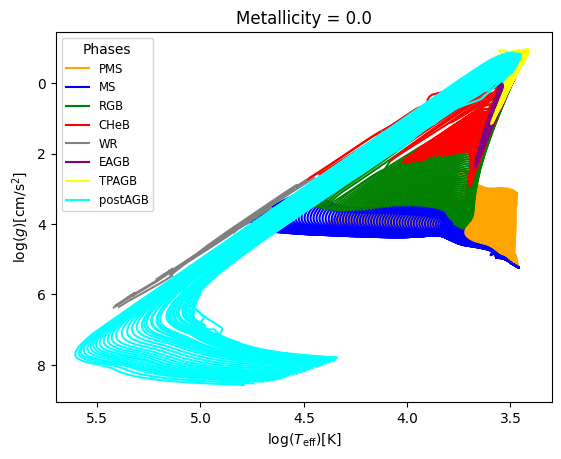

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
630600,10.3,3.602322,1.827453,3.0,0.50,0.866616,1.274247
630601,10.3,3.600999,1.809405,3.0,0.50,0.866614,1.283270
630602,10.3,3.599710,1.791489,3.0,0.50,0.866612,1.292228
630603,10.3,3.598418,1.773621,3.0,0.50,0.866610,1.301161


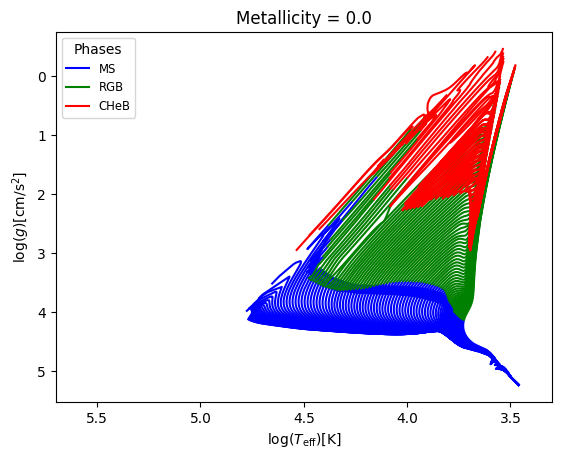

In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [8]:
print_all_uniques(phase_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.1154, Median : 8.15

log_Teff  : Range : 3.34 - 5.3788, Mean : 4.0283, Median : 3.9761

log_g  : Range : -1.08 - 6.2594, Mean : 3.5075, Median : 3.8521

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 298.5448, Mean : 11.4145, Median : 2.8996

log_R  : Range : -1.0 - 3.1298, Mean : 0.735, Median : 0.7005



In [9]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 298.5447575808816
Median value in train data for the star_mass parameter: 2.900660435695107
Mean value in train data for the star_mass parameter: 11.448959764246645

Range in train data for the log_R parameter : -0.9974628481553472 - 3.129269620812593
Median value in train data for the log_R parameter: 0.7005259212303901
Mean value in train data for the log_R parameter: 0.7346615625058007

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999984244466985 - 295.93050489035244
Median value in test data for the star_mass parameter: 2.89581954298918
Mean value in test data for the star_mass parameter: 11.31127918999169

Range in test data for the log_R parameter : -0.9974747647513328 - 3.1297545143214007
Median value in test data for the log_R parameter: 0.700308157259431
Mean value in test data for the log_R parameter: 0.7362027655401773

(472953, 4) (157652, 4)
(47295

## Model training

### Linear regression

In [10]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.22915297336788532
  RMSE :  23.096360859998658
  MAE :  13.001161474977412
  MedAE :  10.681151185415073
  CORR :  0.48939493352978375
  MAX_ER :  265.67198326110986
  Percentiles : 
    75th percentile :  14.670357426164667
    90th percentile :  18.974079268967056
    95th percentile :  20.712577909625935
    99th percentile :  108.2672863343865

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.30075995262325006
  RMSE :  24.83082785963063
  MAE :  11.024236863373494
  MedAE :  6.9482531103523915
  CORR :  0.574908463952895
  MAX_ER :  248.37455790455888
  Percentiles : 
    75th percentile :  12.012164454460352
    90th percentile :  14.130536783201734
    95th percentile :  24.1033695

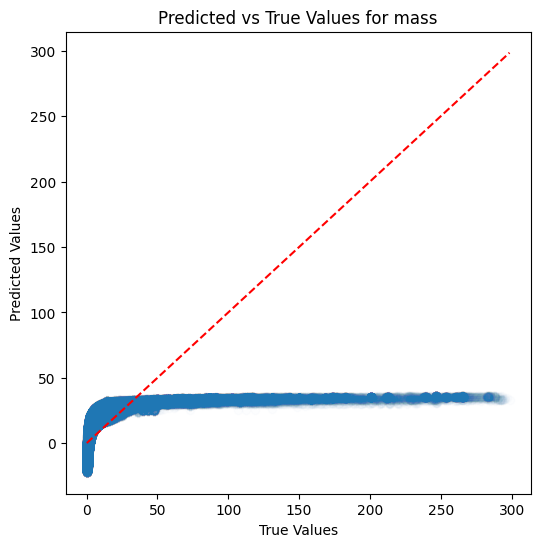

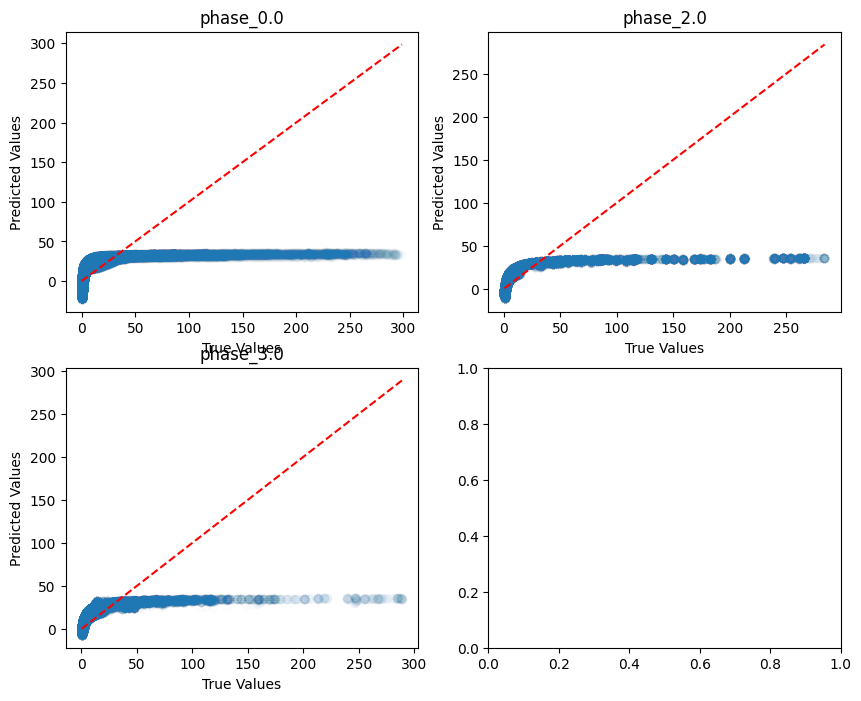

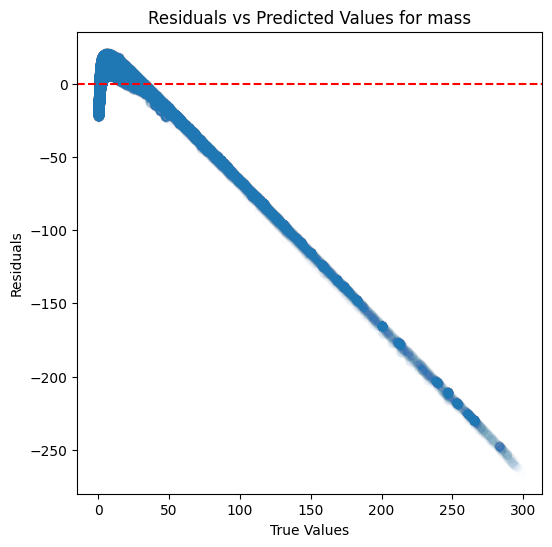

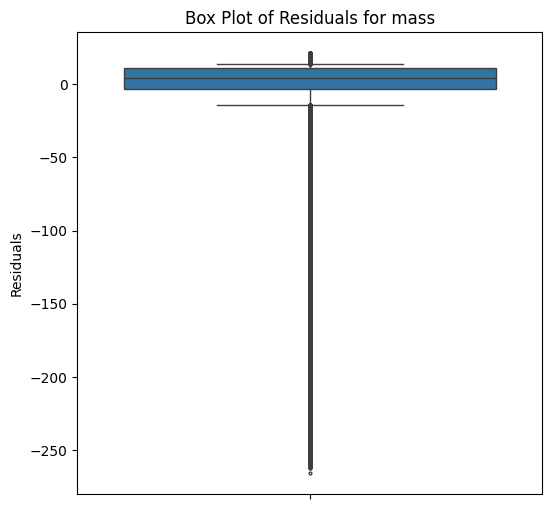

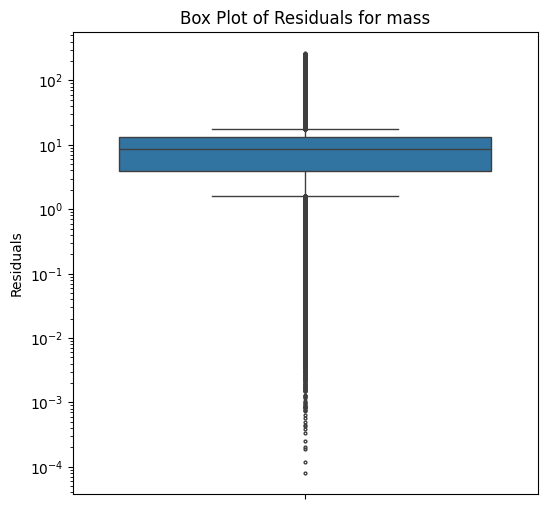

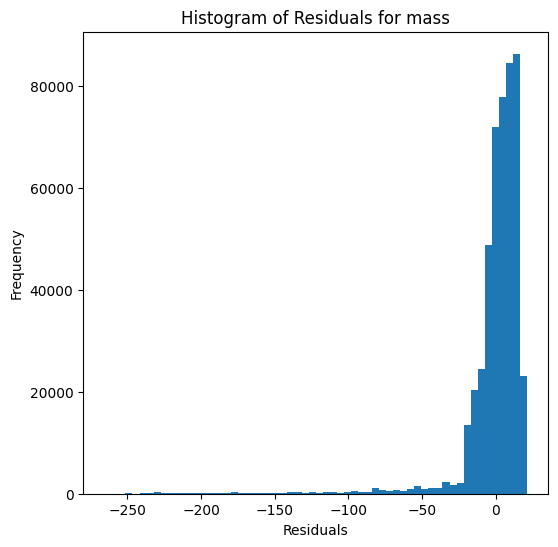

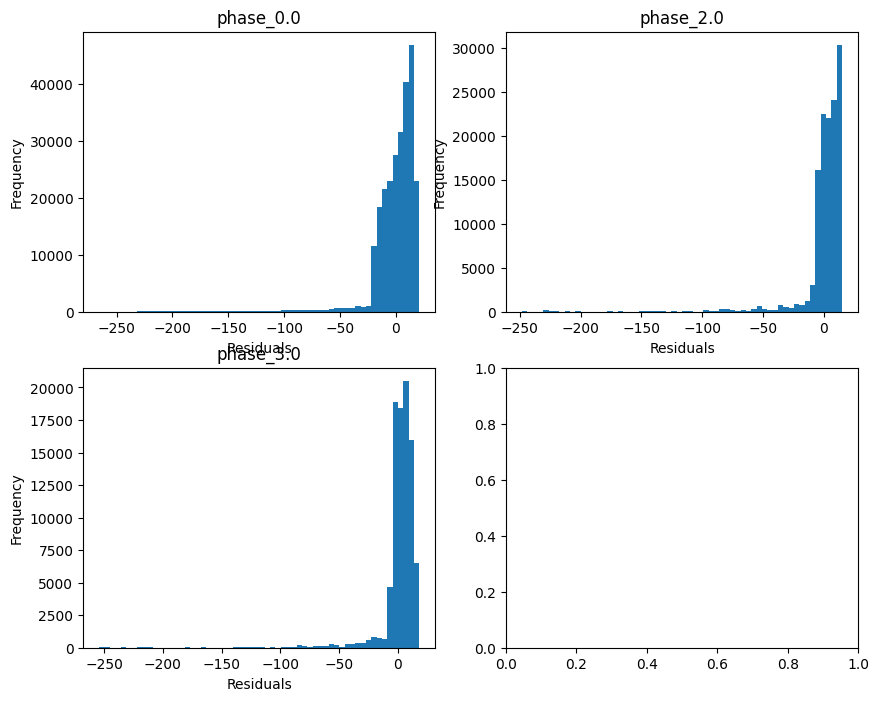

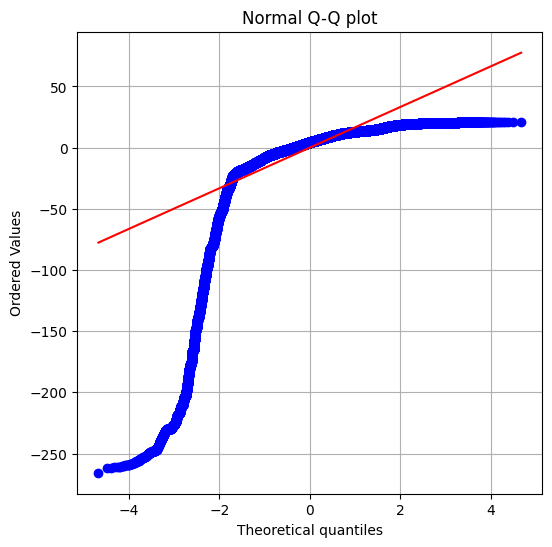

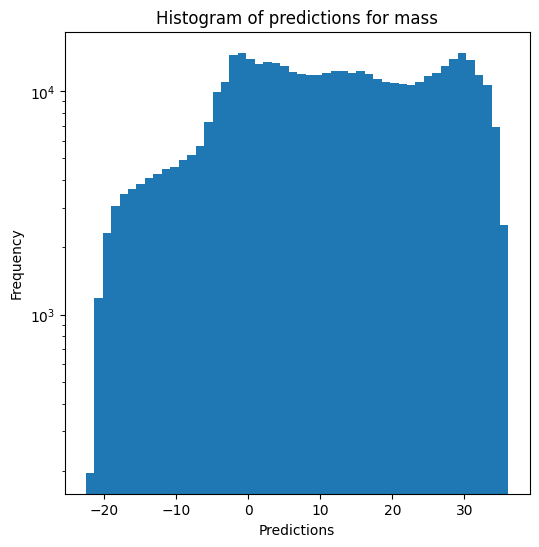

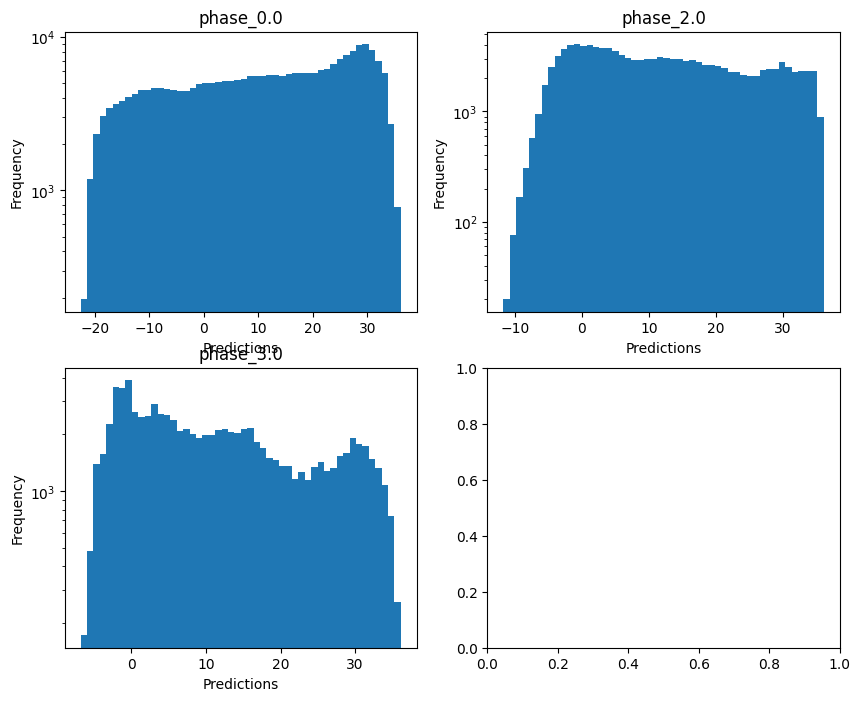

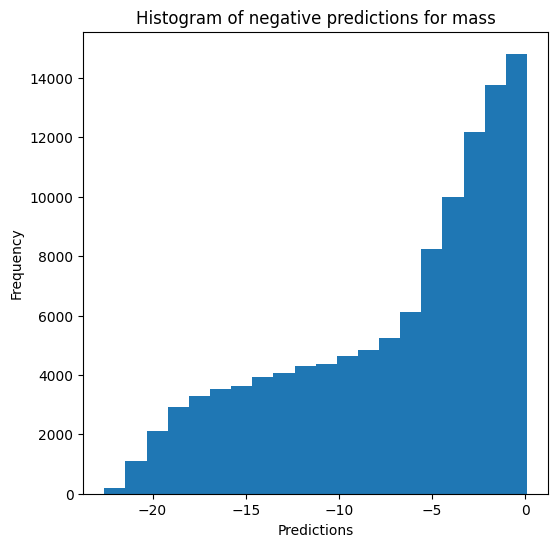


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9177461475823924
  RMSE :  0.1648869806735937
  MAE :  0.12850037068125983
  MedAE :  0.09959601709077412
  CORR :  0.9585022400038563
  MAX_ER :  0.7708438224027148
  Percentiles : 
    75th percentile :  0.18605271911623594
    90th percentile :  0.27371683376831857
    95th percentile :  0.325065395383159
    99th percentile :  0.4584753353423104

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9144048268257878
  RMSE :  0.15198568997662273
  MAE :  0.12594426376778078
  MedAE :  0.11907528910868426
  CORR :  0.9631141916458649
  MAX_ER :  0.8761632702604465
  Percentiles : 
    75th percentile :  0.16265718175633914
    90th percentile :  0.20002633146310683
    95th percentile :  0.2698779929935464
    99th percentile :  0.45174664372039053

radius results for the phase category 

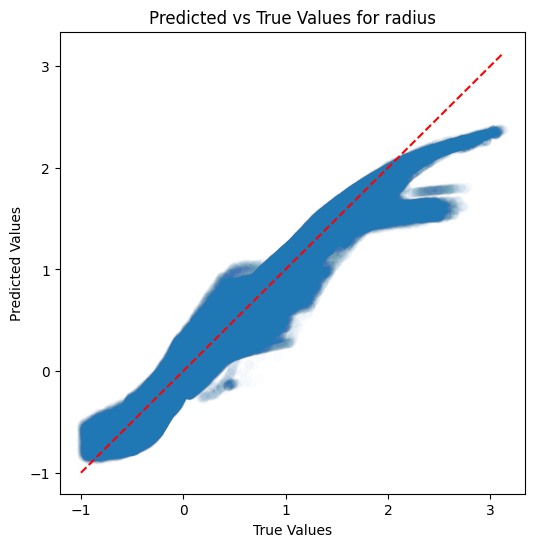

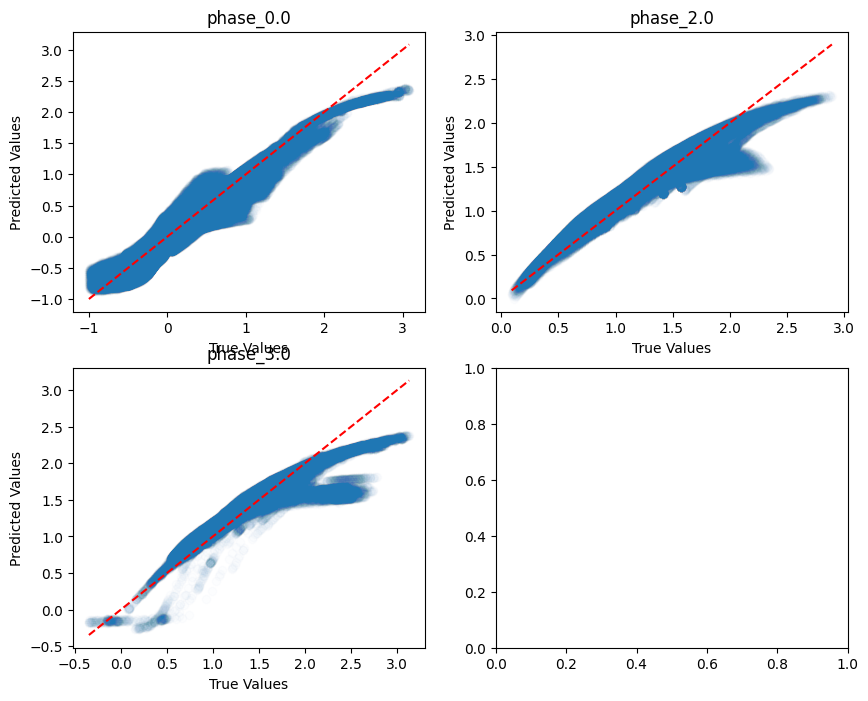

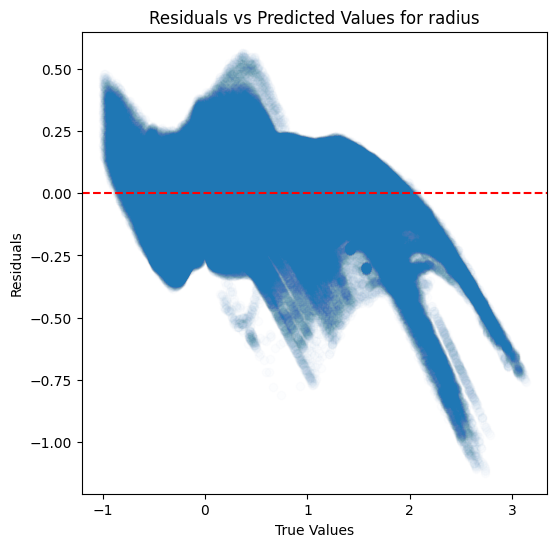

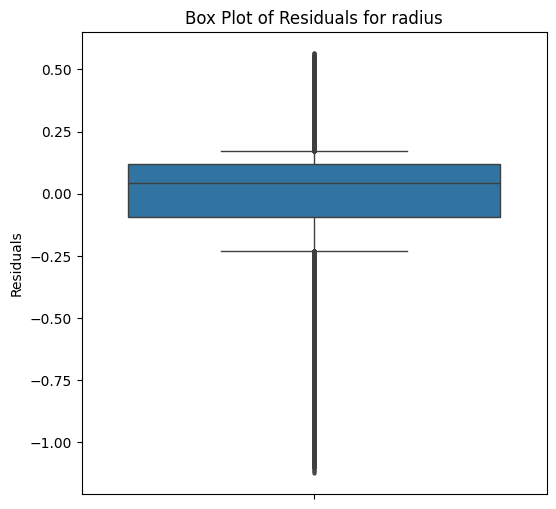

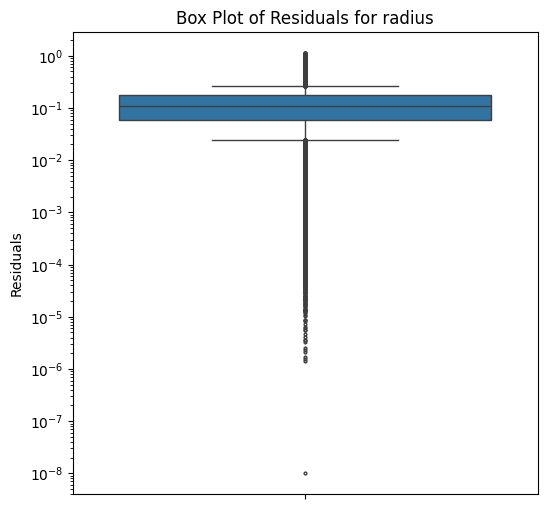

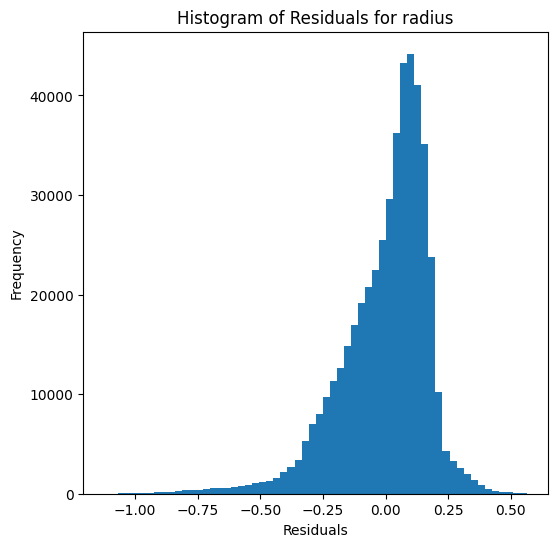

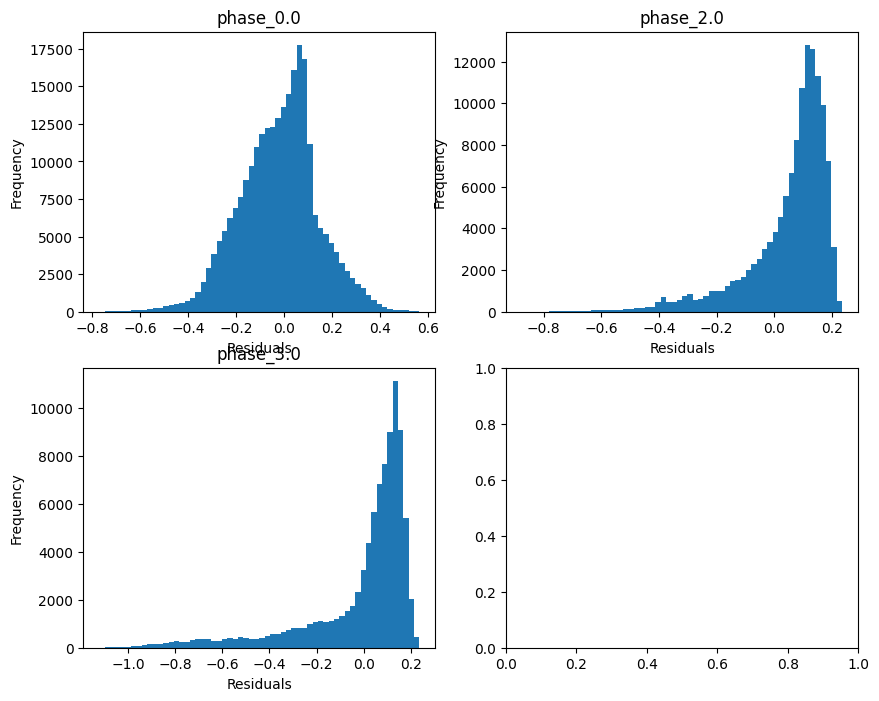

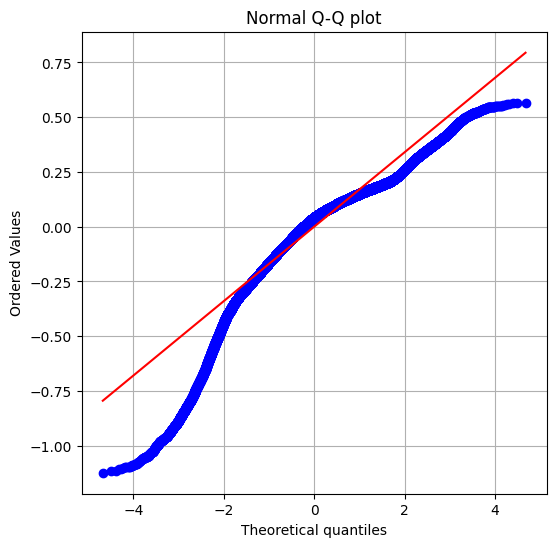

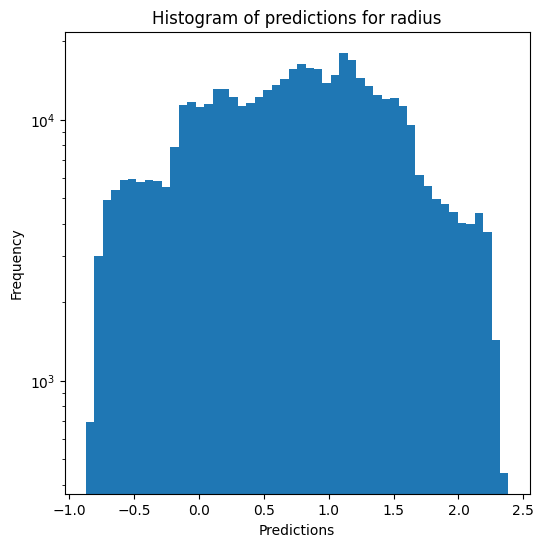

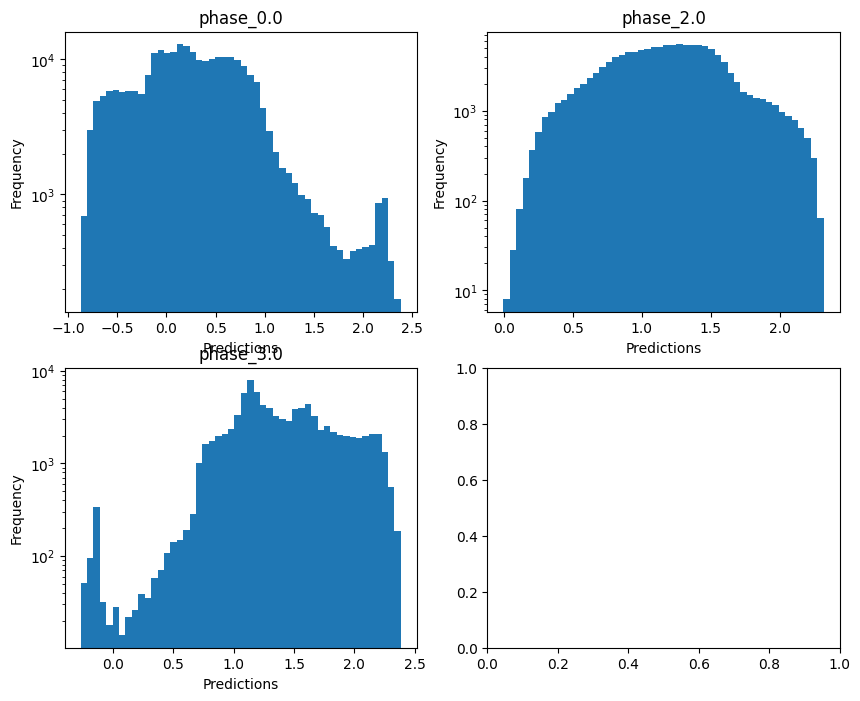

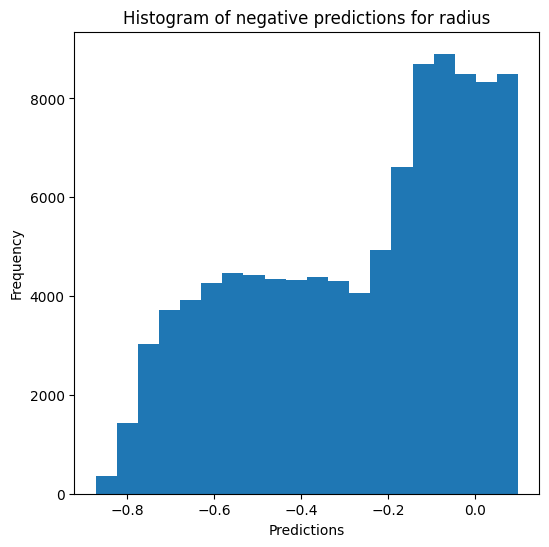

Saving predictions and results...


In [11]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name) #, override=False, use_preds=True

### Decision tree

In [12]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9936853423995572
  RMSE :  2.0900372356735186
  MAE :  0.2681242805674491
  MedAE :  0.005933565692025633
  CORR :  0.9968582092538901
  MAX_ER :  131.77529017024463
  Percentiles : 
    75th percentile :  0.03077428747700872
    90th percentile :  0.1846864262959258
    95th percentile :  0.6697820926631993
    99th percentile :  5.866302833303478

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9992015439276027
  RMSE :  0.8390954842871678
  MAE :  0.06161788558637096
  MedAE :  0.000351196151331834
  CORR :  0.9996008600501027
  MAX_ER :  110.5726998730886
  Percentiles : 
    75th percentile :  0.0054939434940042275
    90th percentile :  0.025451991428414547
    95th percentile :  0

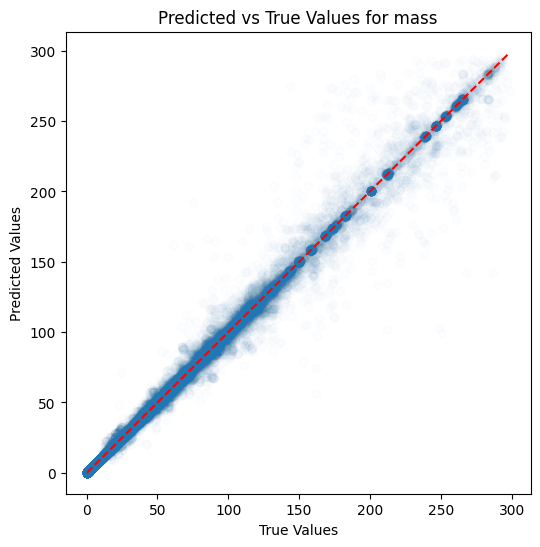

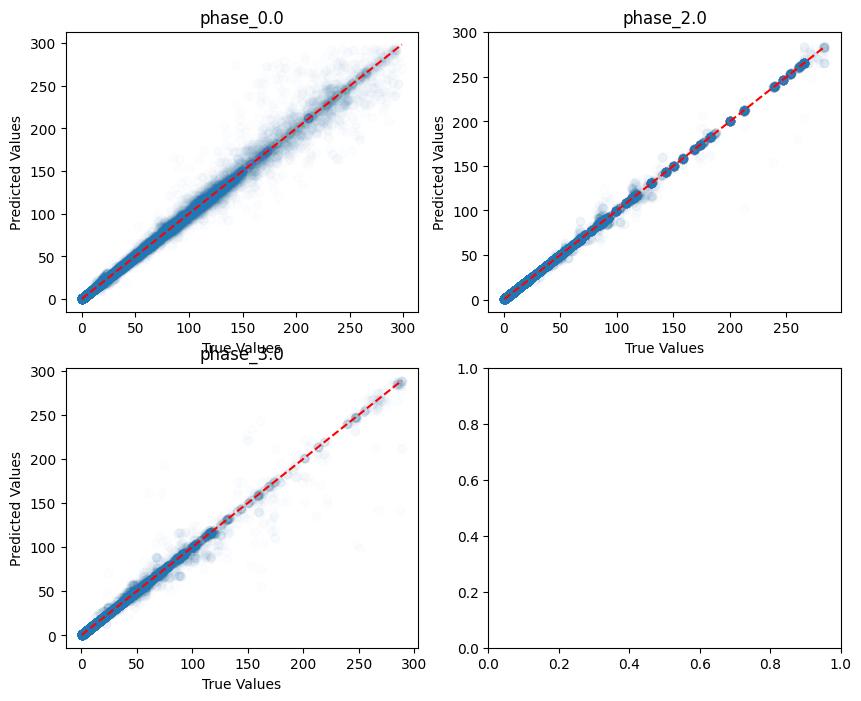

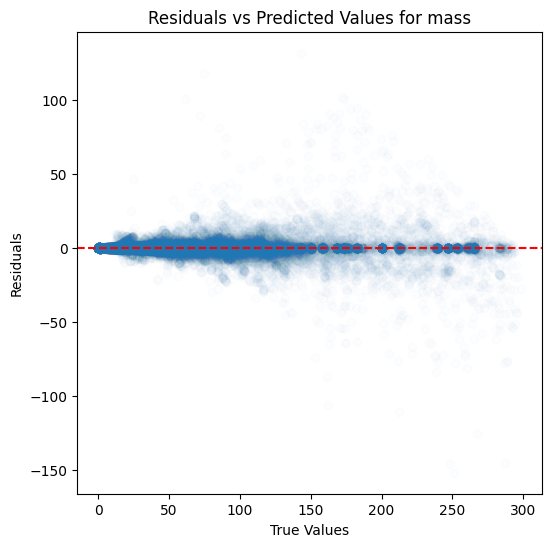

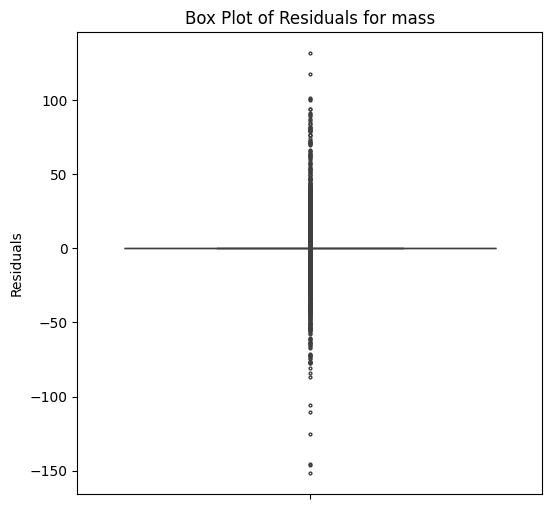

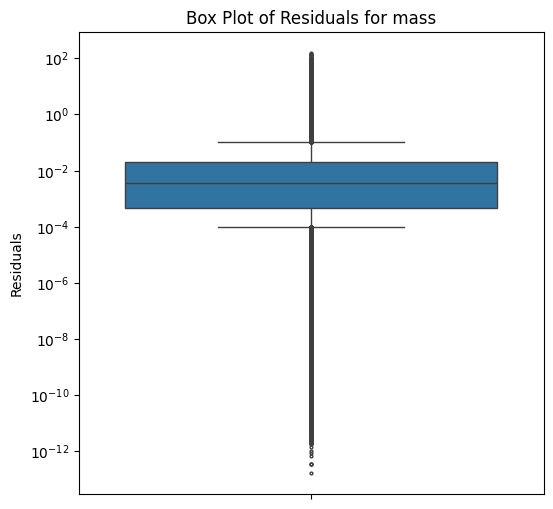

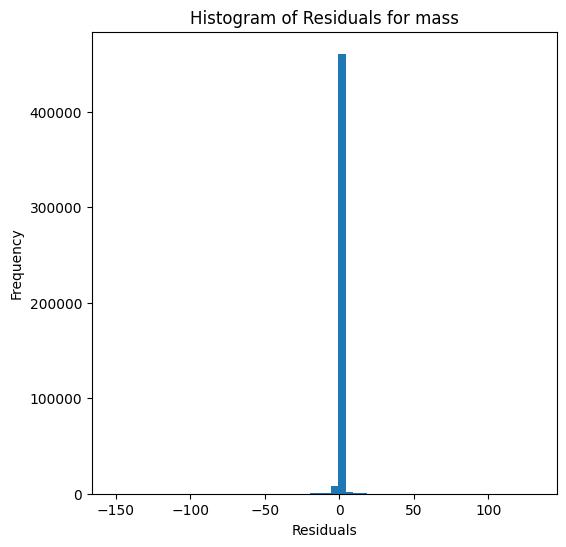

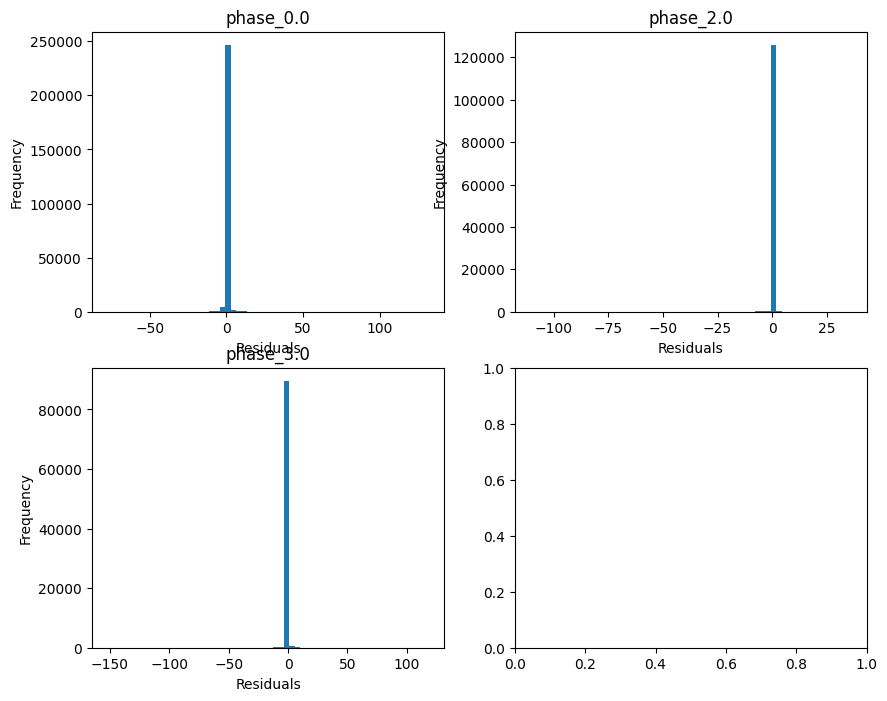

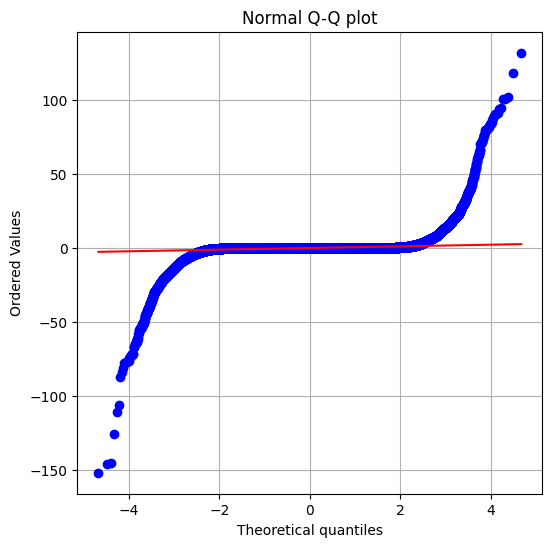

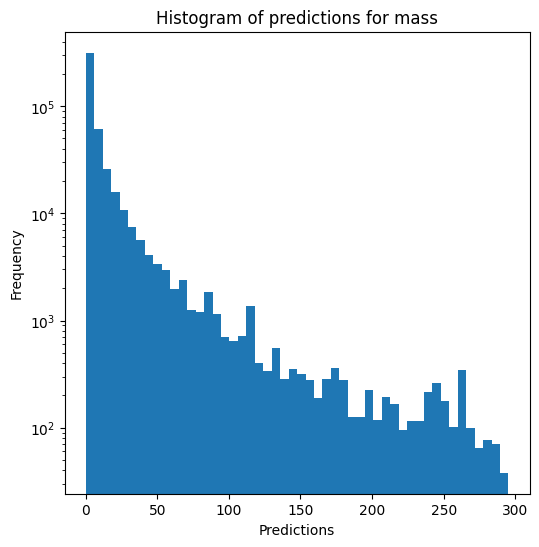

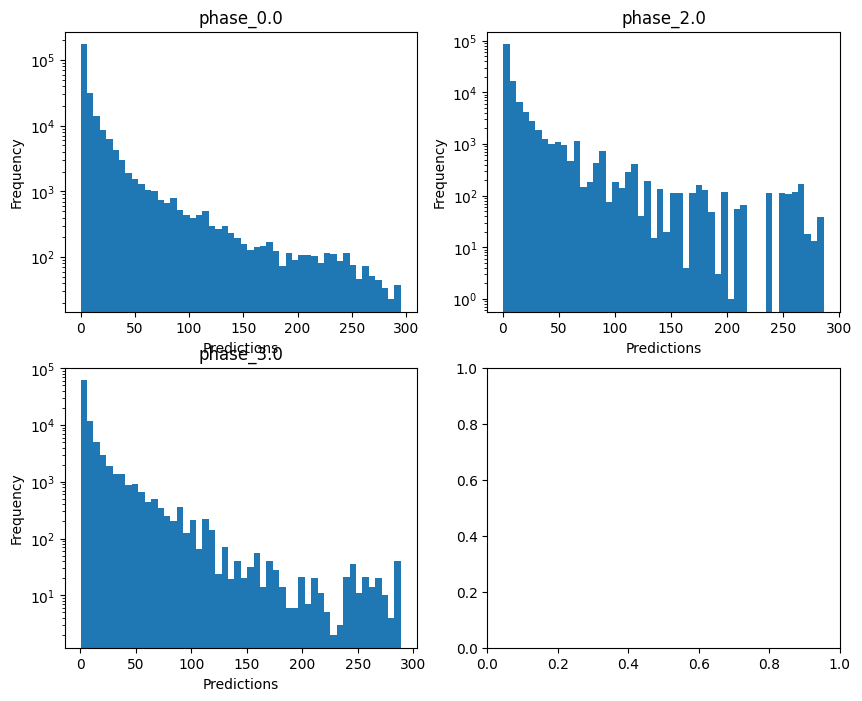

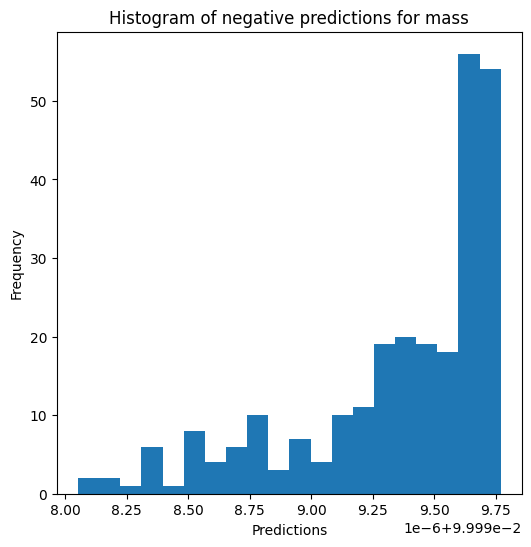


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9997847542449331
  RMSE :  0.008367032449964186
  MAE :  0.004592483463663214
  MedAE :  0.002627462761002043
  CORR :  0.9998924306860204
  MAX_ER :  0.4783497157713891
  Percentiles : 
    75th percentile :  0.005345847826900757
    90th percentile :  0.010251778260113044
    95th percentile :  0.015117075508371861
    99th percentile :  0.03214908926166804

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.999596811370535
  RMSE :  0.009859931798112231
  MAE :  0.0067480672969762396
  MedAE :  0.0052344319440715825
  CORR :  0.9997991043978084
  MAX_ER :  0.22474520387191088
  Percentiles : 
    75th percentile :  0.00908100775091883
    90th percentile :  0.013449862880941058
    95th percentile :  0.01661196500050088
    99th percentile :  0.03162936885300681

radius results for th

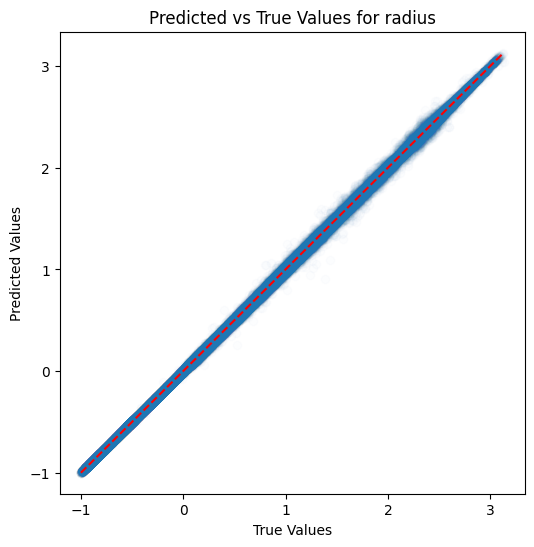

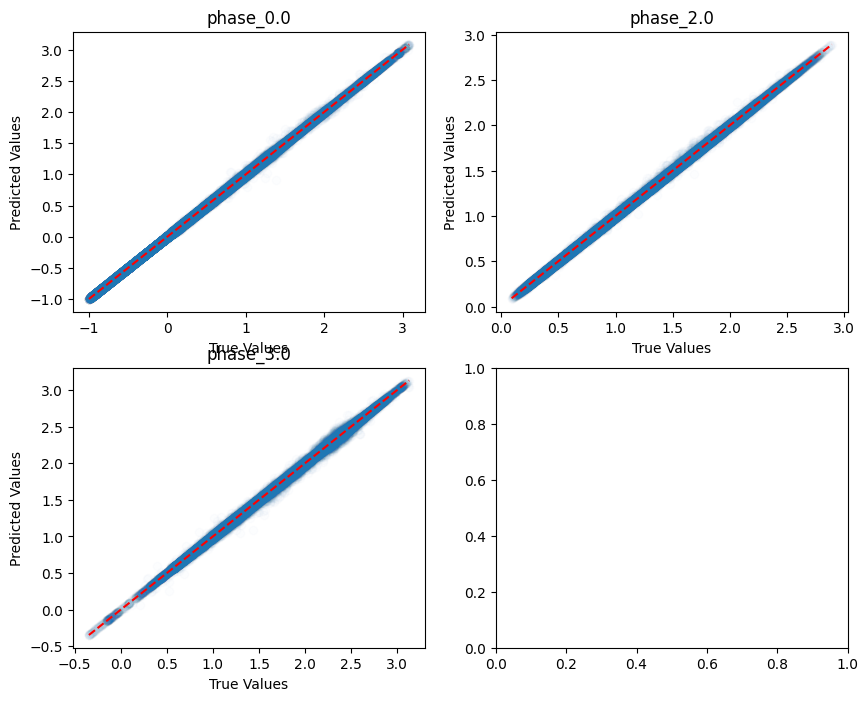

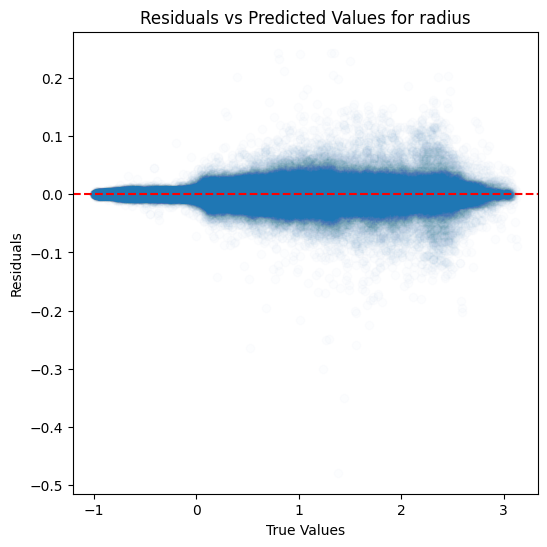

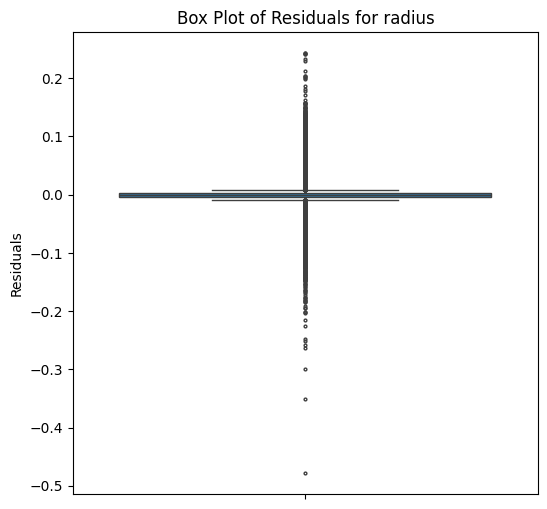

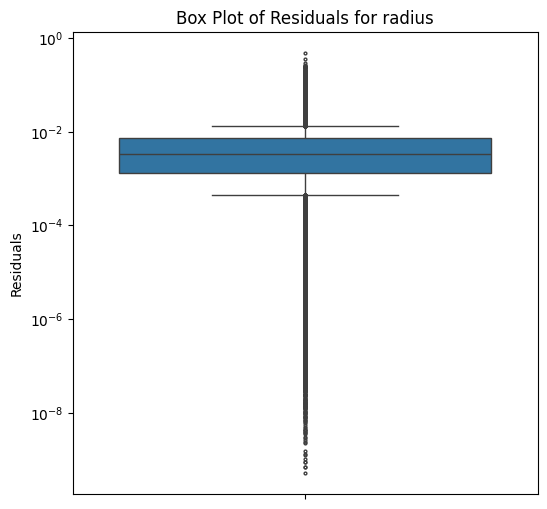

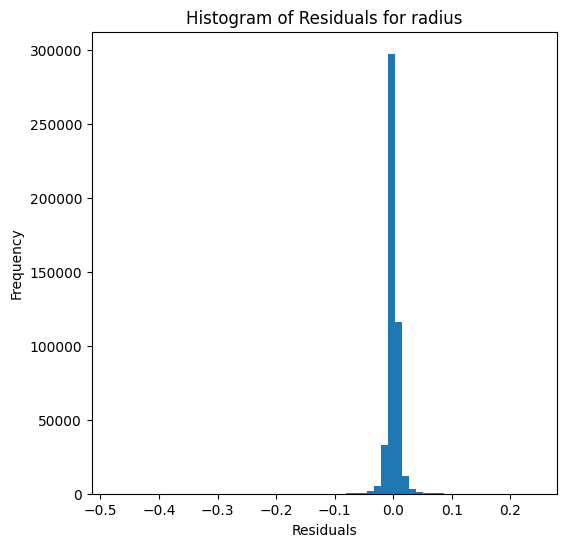

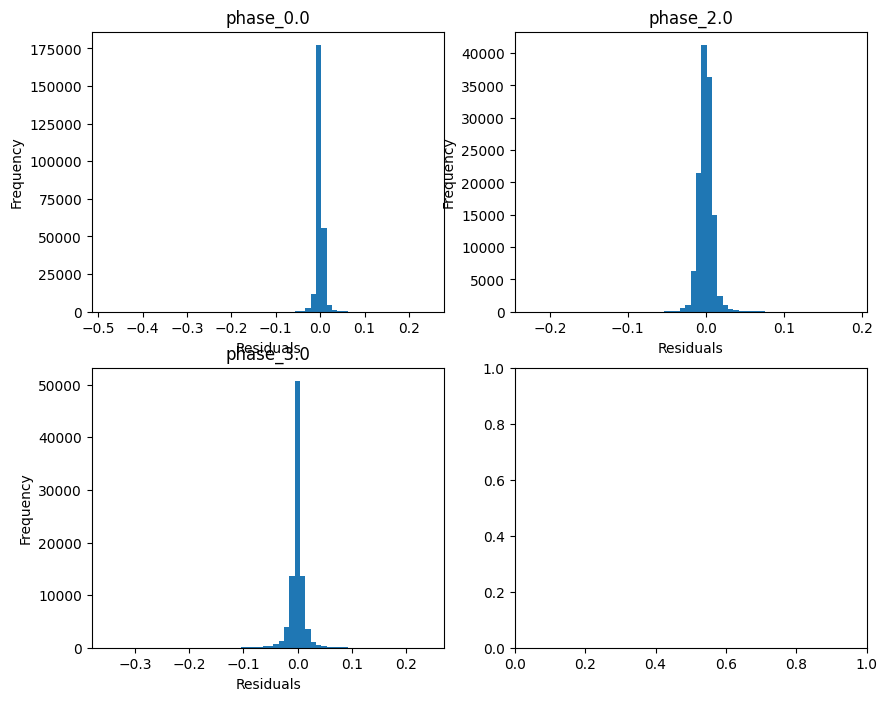

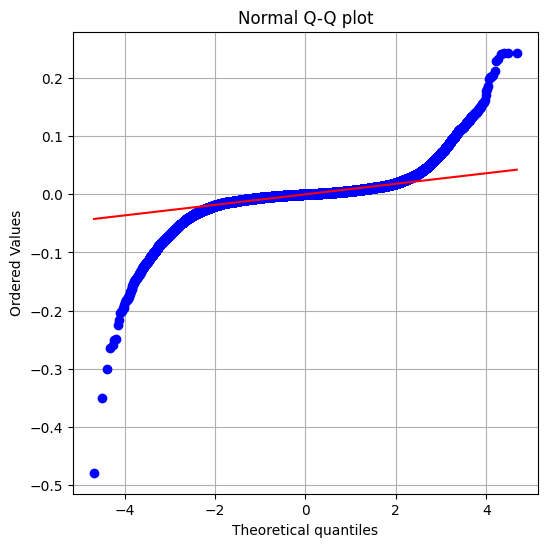

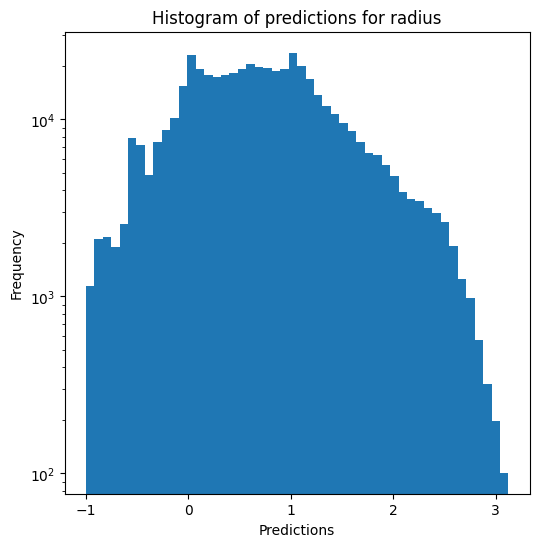

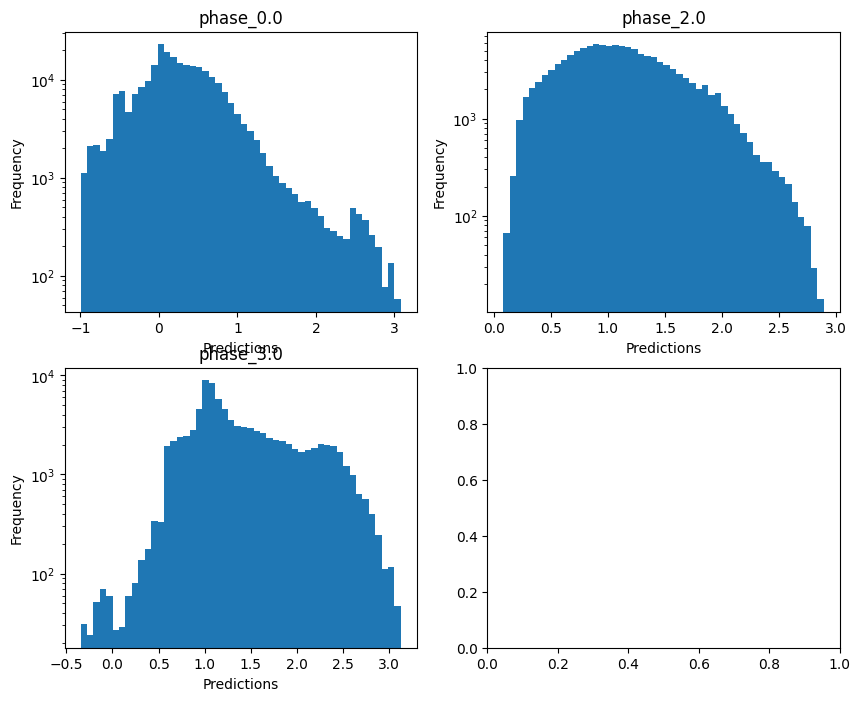

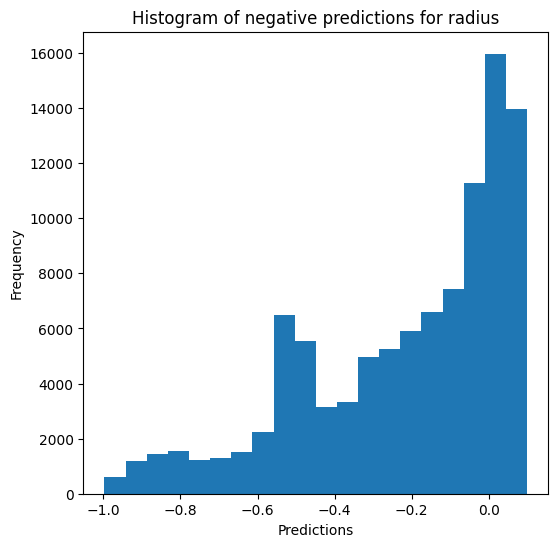

Saving predictions and results...


In [13]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### K-nearest neighbours

In [14]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9905000104675683
  RMSE :  2.5634457545094045
  MAE :  0.34301375346735297
  MedAE :  0.007566469408320842
  CORR :  0.9952928819657935
  MAX_ER :  108.44412812301914
  Percentiles : 
    75th percentile :  0.035108544351275306
    90th percentile :  0.20070085703119342
    95th percentile :  0.812463933192203
    99th percentile :  7.86306201587908

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9993816647987996
  RMSE :  0.7384042243890899
  MAE :  0.08341663859779695
  MedAE :  0.003095593056968937
  CORR :  0.9996910307263401
  MAX_ER :  43.59163383937107
  Percentiles : 
    75th percentile :  0.01732612065141037
    90th percentile :  0.07774214182737485
    95t

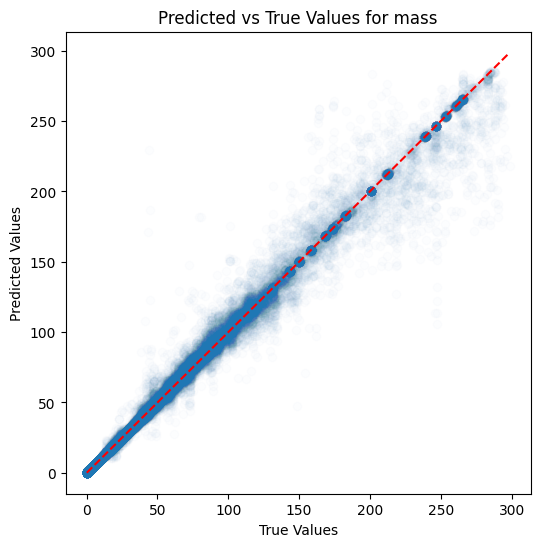

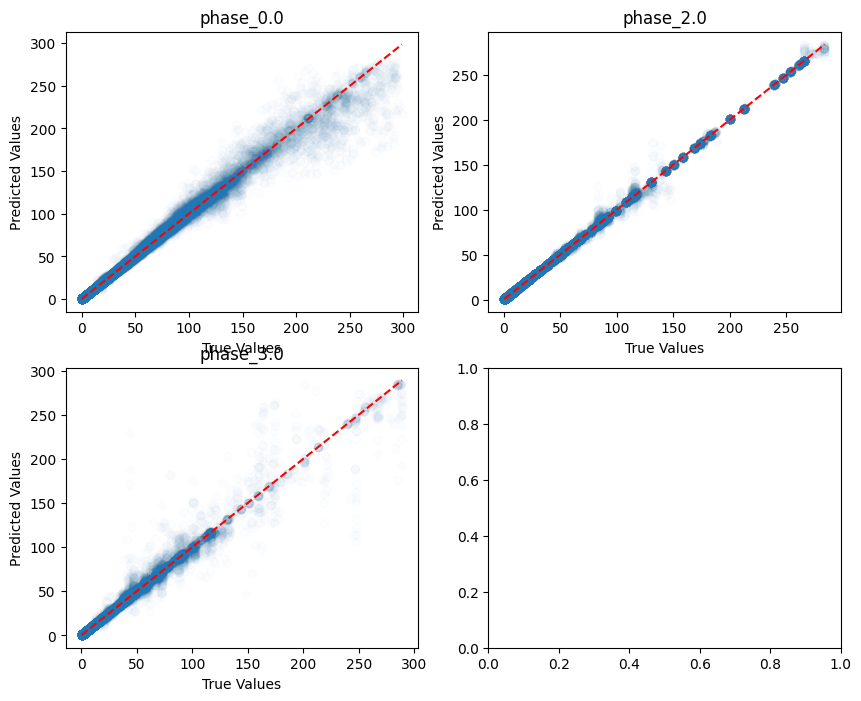

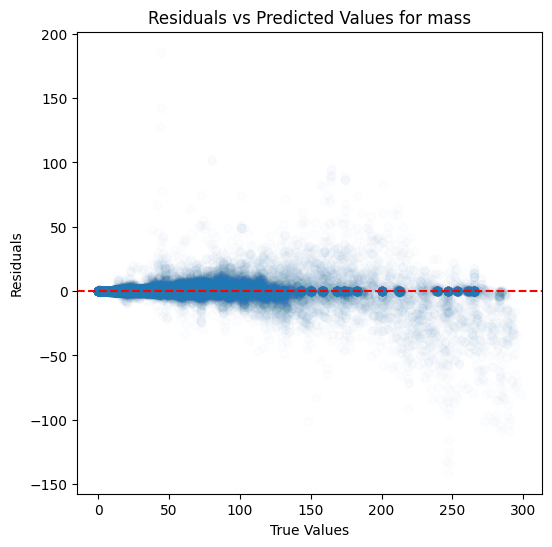

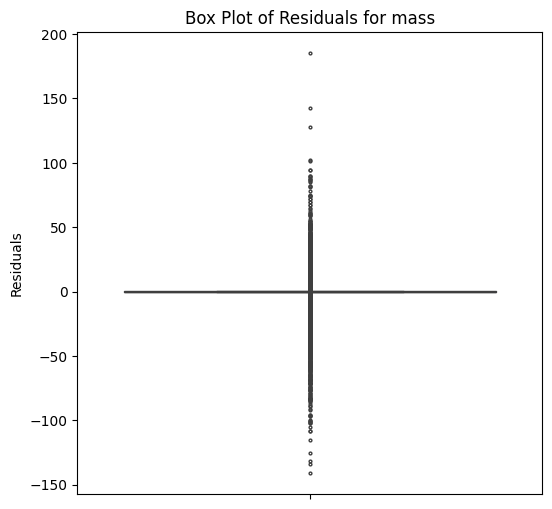

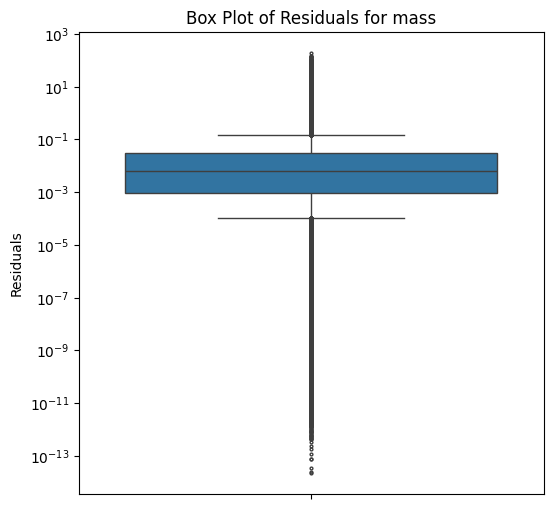

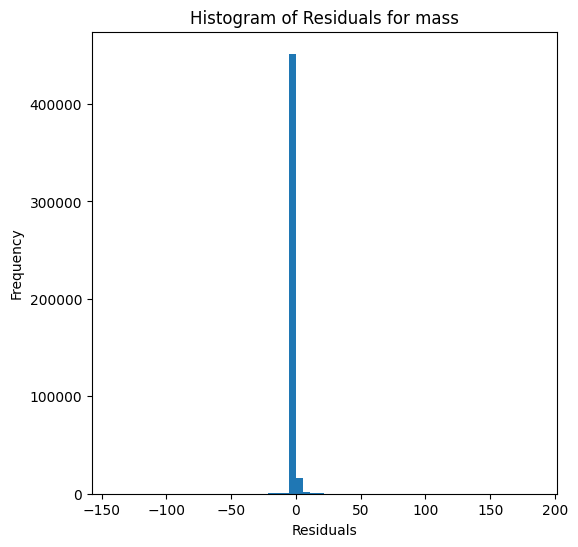

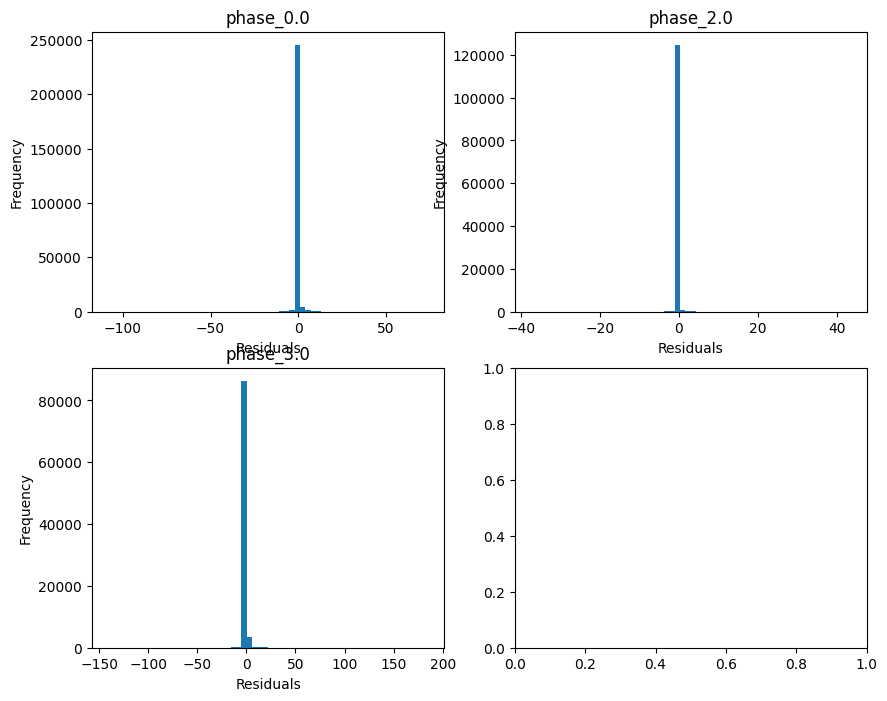

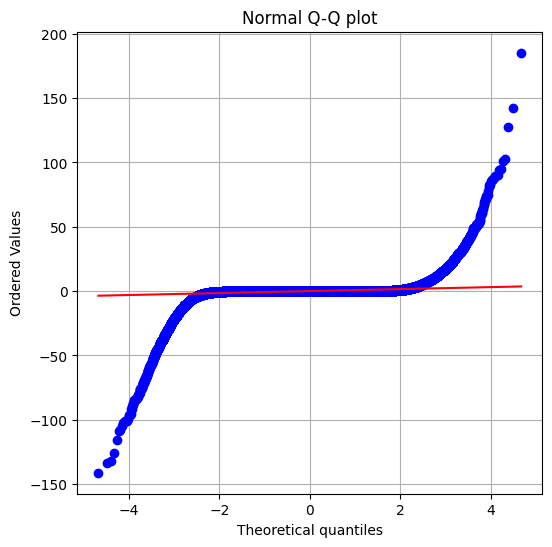

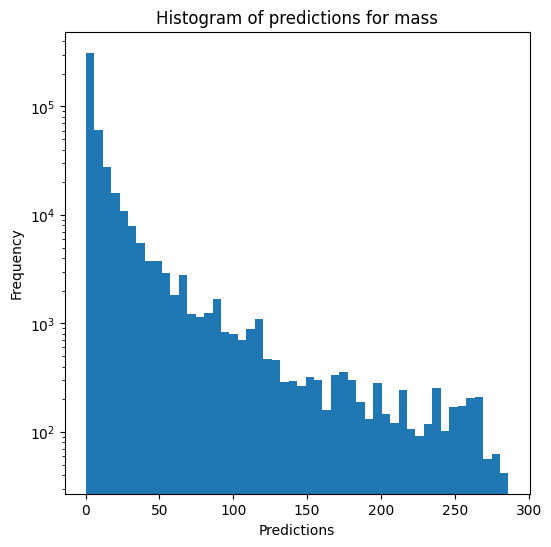

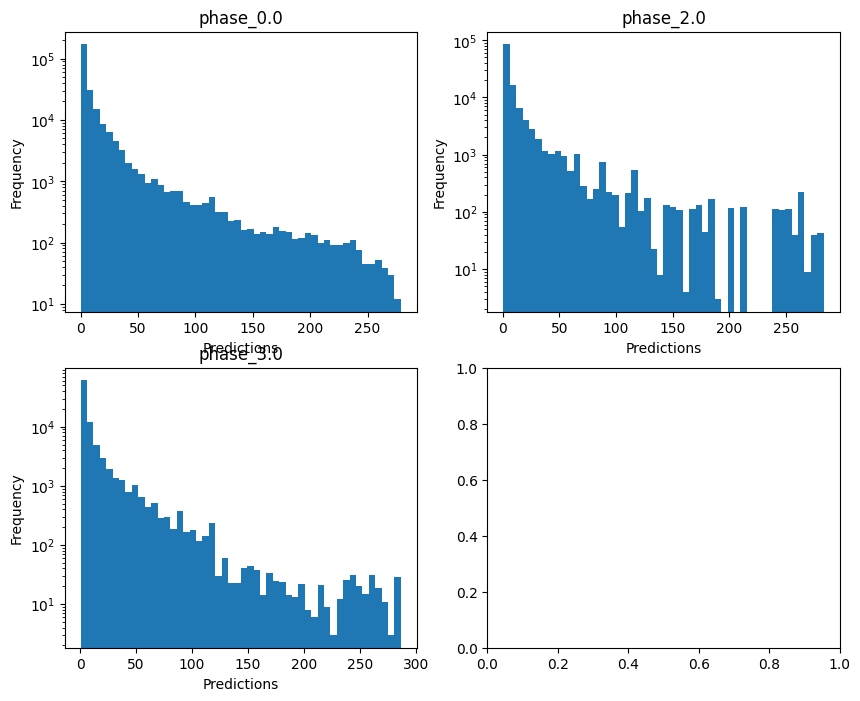


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9998577763461787
  RMSE :  0.006803056868753319
  MAE :  0.0035458117431640796
  MedAE :  0.0019418301833866447
  CORR :  0.9999288857513364
  MAX_ER :  0.1443101737871877
  Percentiles : 
    75th percentile :  0.003892001544729351
    90th percentile :  0.007582943883037158
    95th percentile :  0.011789379273166957
    99th percentile :  0.029468384911947598

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9997790095960687
  RMSE :  0.007355178725255613
  MAE :  0.005034670179408442
  MedAE :  0.003442477818386358
  CORR :  0.999891804306905
  MAX_ER :  0.1353371745880514
  Percentiles : 
    75th percentile :  0.006791319223126452
    90th percentile :  0.011406711700975493
    95th percentile :  0.01512214418129175
    99th percentile :  0.024850432465749448

radius results for 

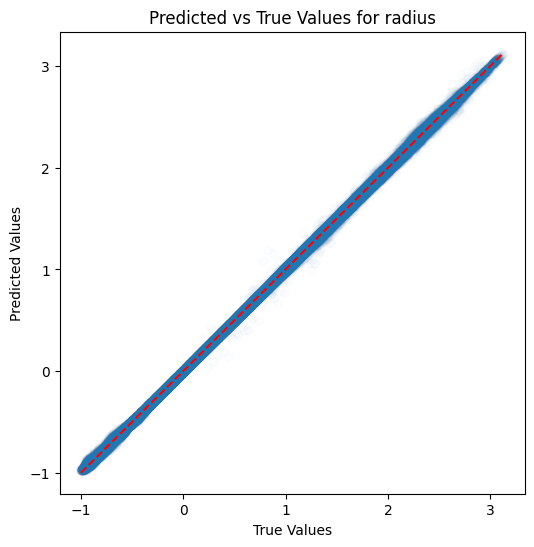

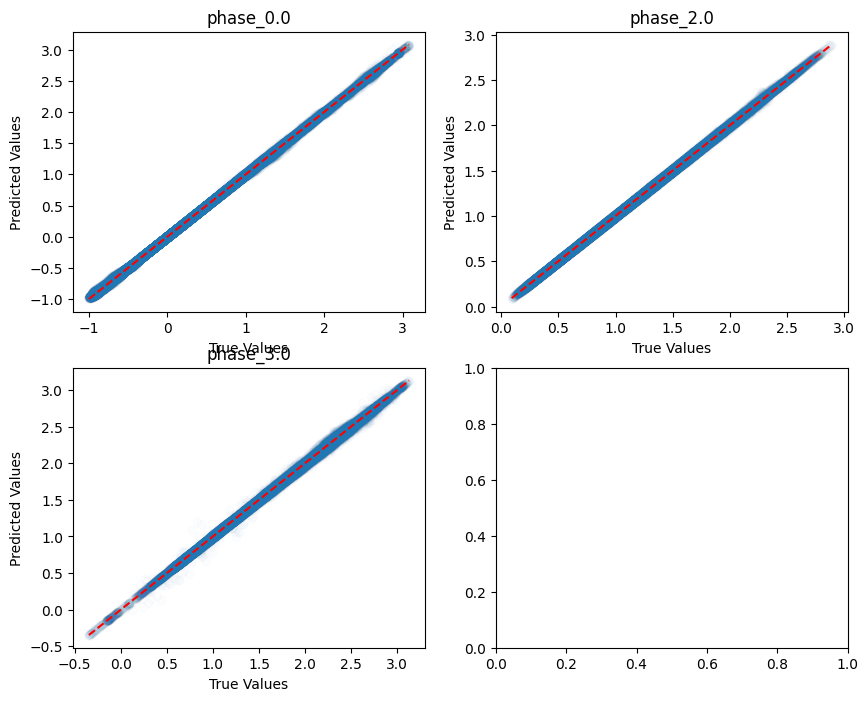

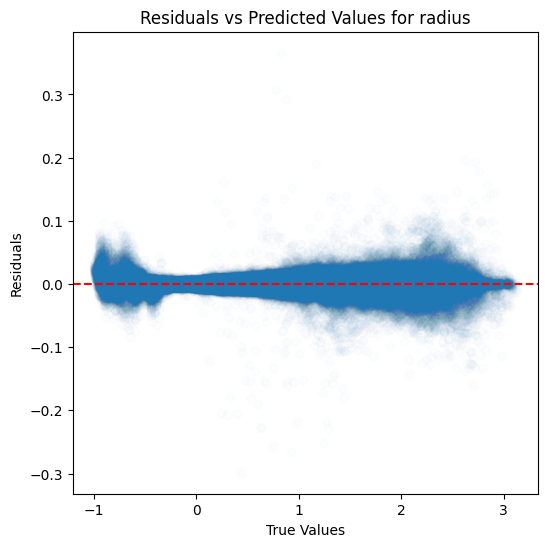

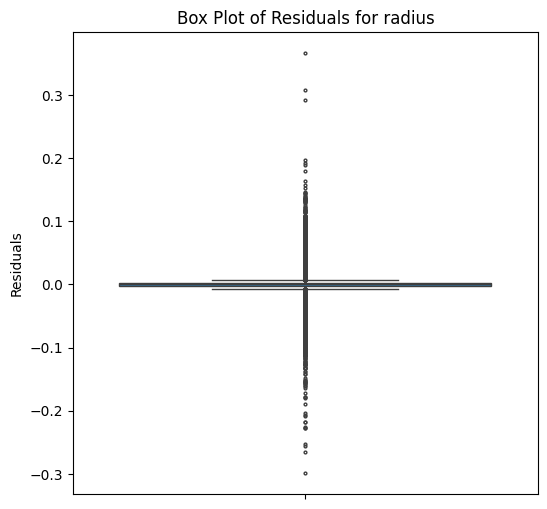

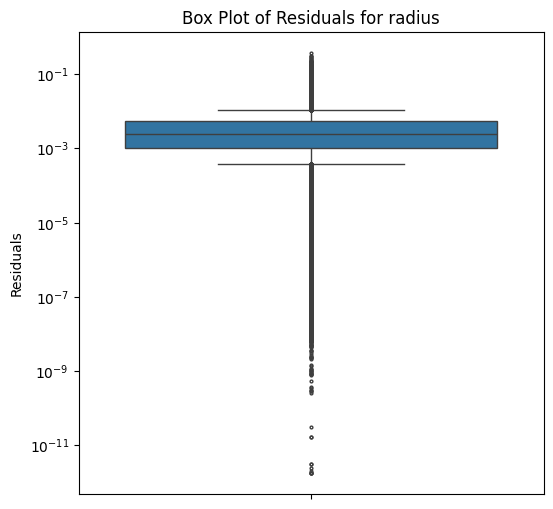

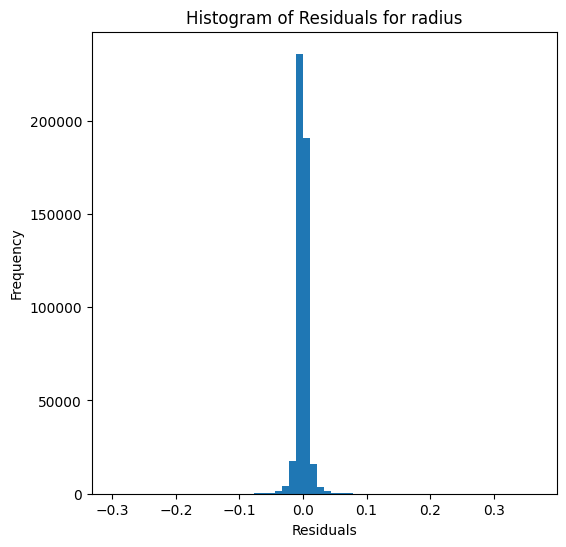

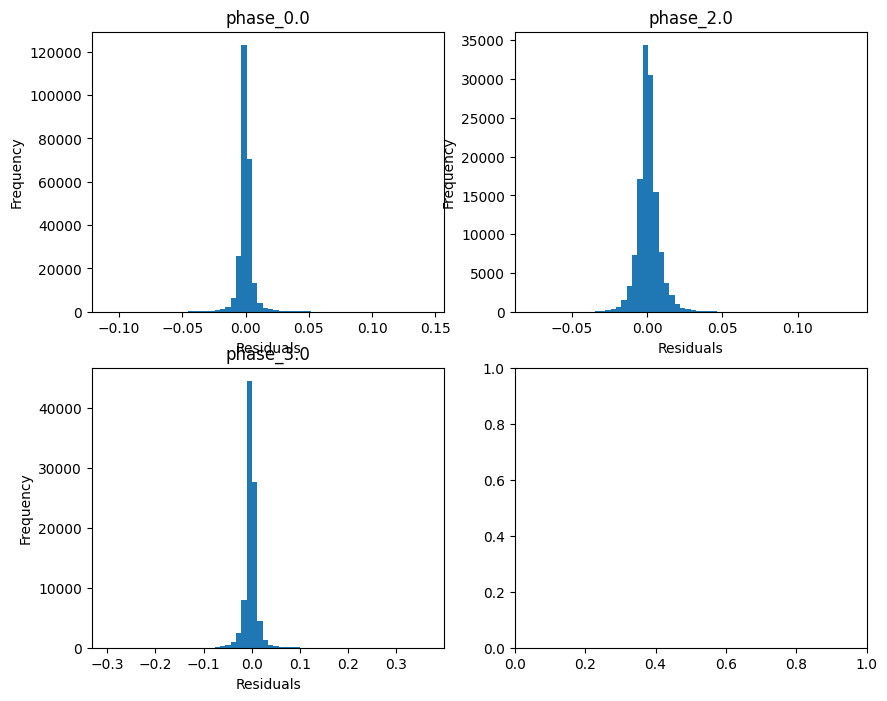

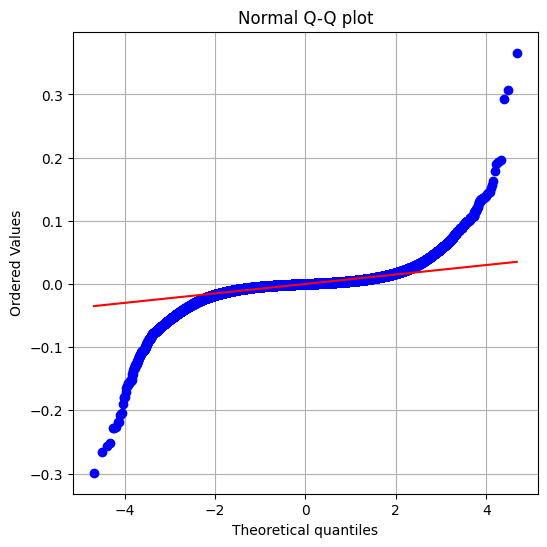

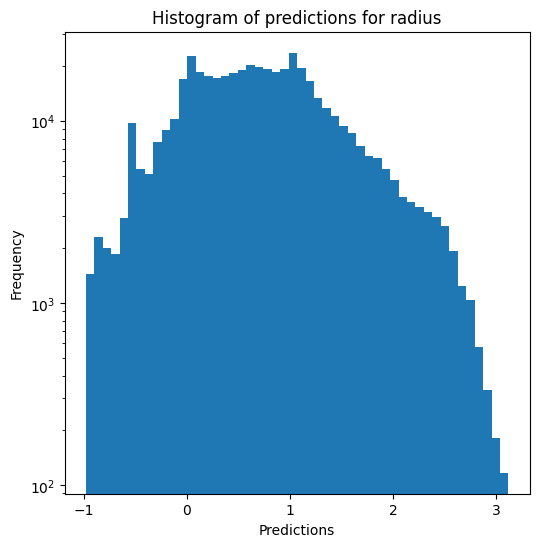

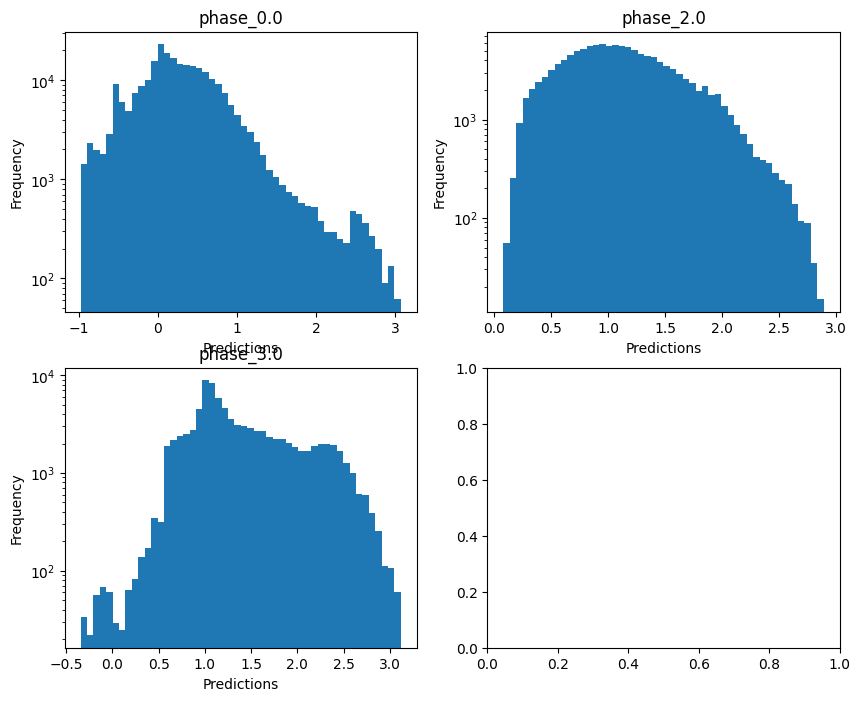

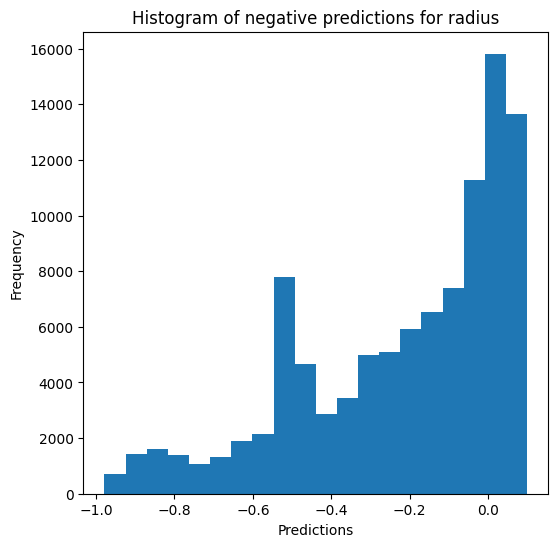

Saving predictions and results...


In [15]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### Random forests

In [16]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9973643192236208
  RMSE :  1.3504707064716939
  MAE :  0.16794820912705424
  MedAE :  0.0035672109297881782
  CORR :  0.9986828641899517
  MAX_ER :  83.51673867686375
  Percentiles : 
    75th percentile :  0.016581818471481435
    90th percentile :  0.10804424164901331
    95th percentile :  0.42059005048813636
    99th percentile :  3.6259840983190825

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9997423050066863
  RMSE :  0.4767192720890867
  MAE :  0.05948580666893549
  MedAE :  0.004034993095826778
  CORR :  0.9998717674733442
  MAX_ER :  23.444617879426772
  Percentiles : 
    75th percentile :  0.010684304710221082
    90th percentile :  0.025704174836026192
    95th percentile

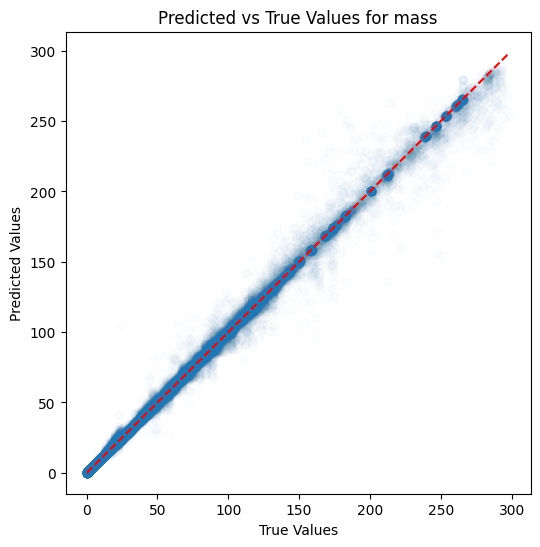

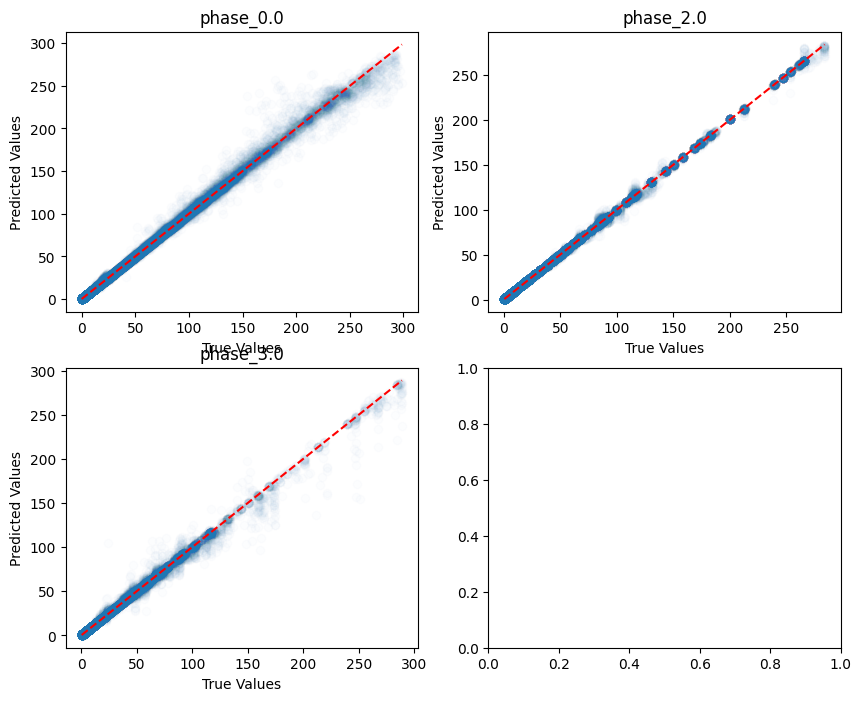

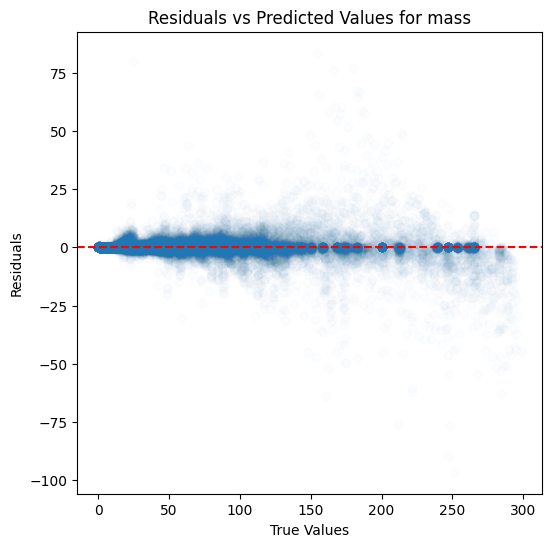

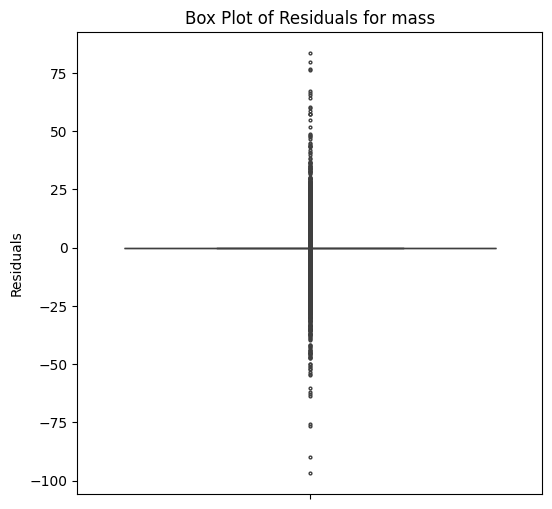

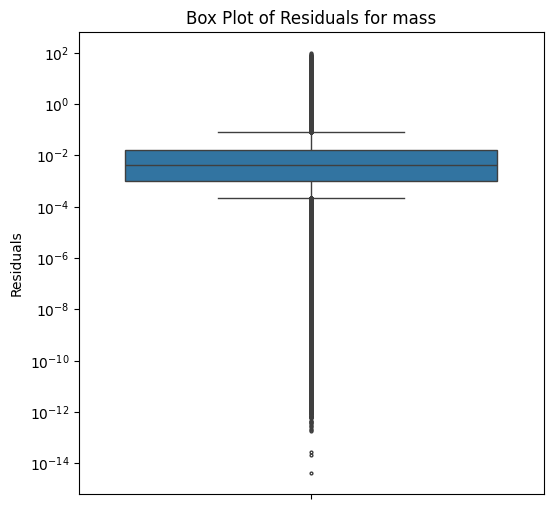

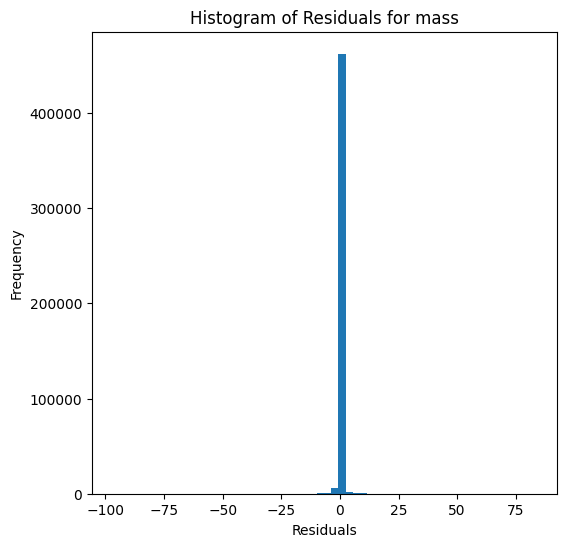

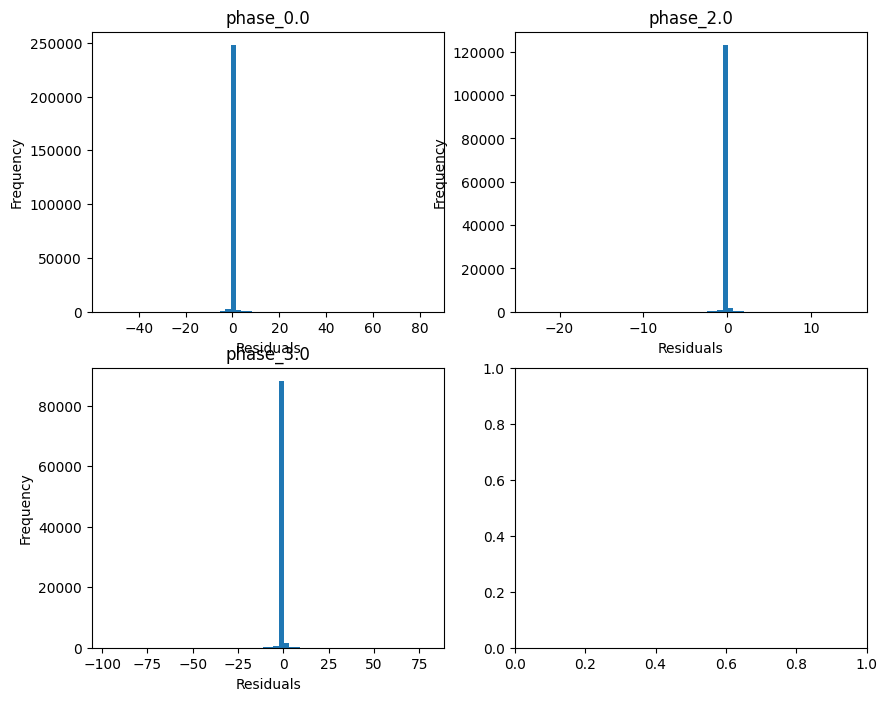

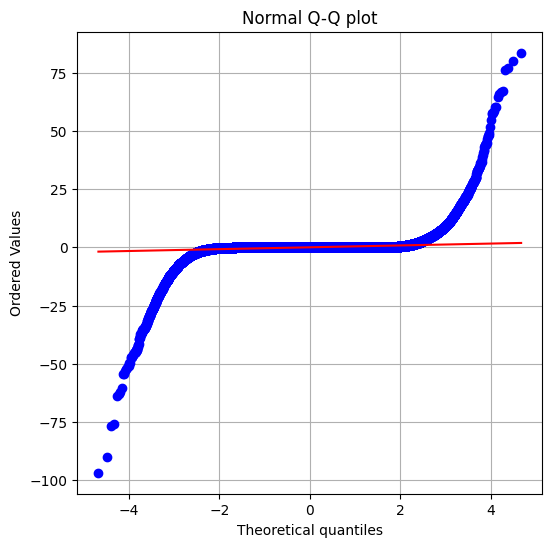

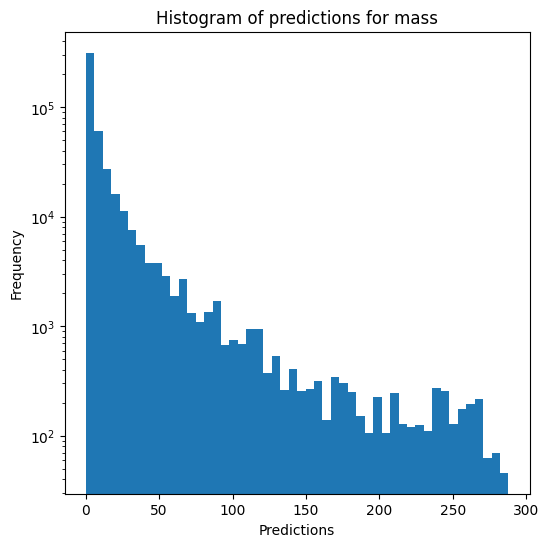

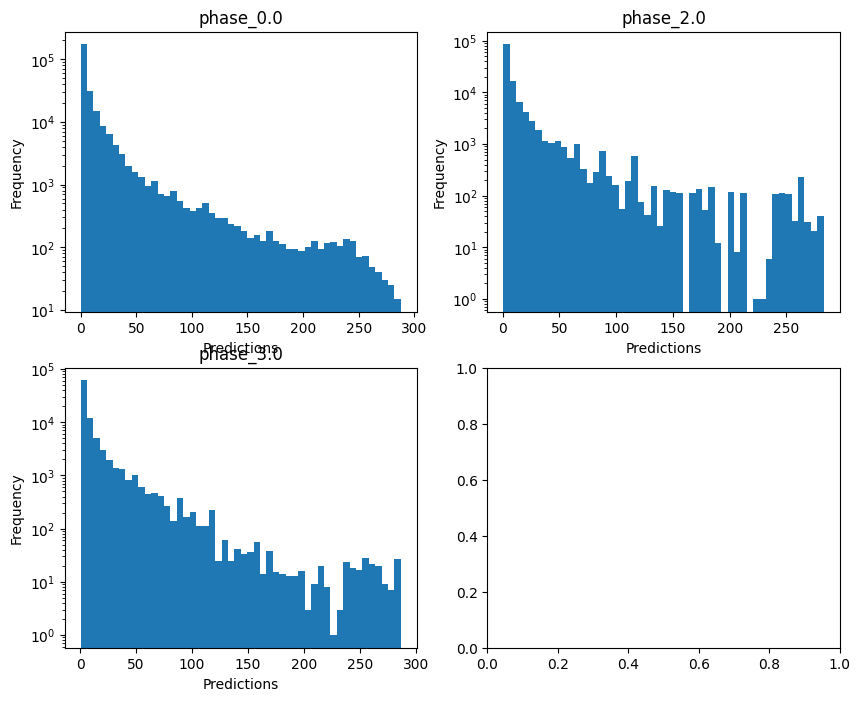

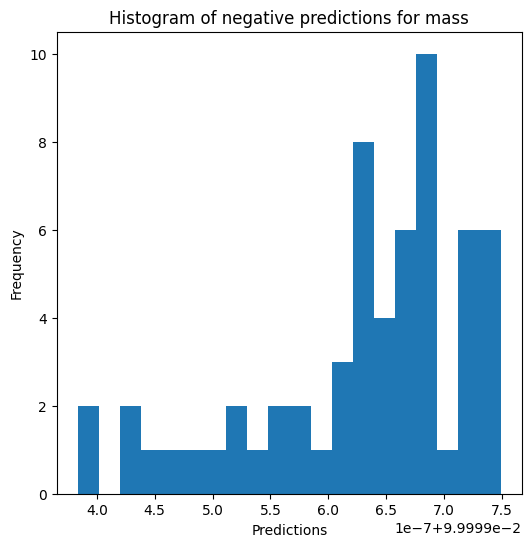


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9999457010003017
  RMSE :  0.004203332087762961
  MAE :  0.002097758039686202
  MedAE :  0.0010233432739523152
  CORR :  0.9999729107113497
  MAX_ER :  0.3722028055290456
  Percentiles : 
    75th percentile :  0.0023405452043645802
    90th percentile :  0.004860769277743884
    95th percentile :  0.0075464715106687095
    99th percentile :  0.016551023637443638

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9999328241081014
  RMSE :  0.004053833232054259
  MAE :  0.0026966885821218148
  MedAE :  0.001794357623006393
  CORR :  0.9999668909119557
  MAX_ER :  0.09941257470715192
  Percentiles : 
    75th percentile :  0.0036177765749882407
    90th percentile :  0.006150784832744627
    95th percentile :  0.008203209500179161
    99th percentile :  0.013987938653645822

radius result

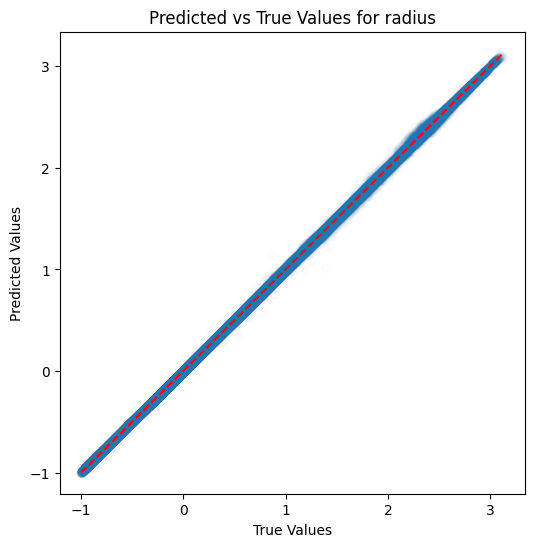

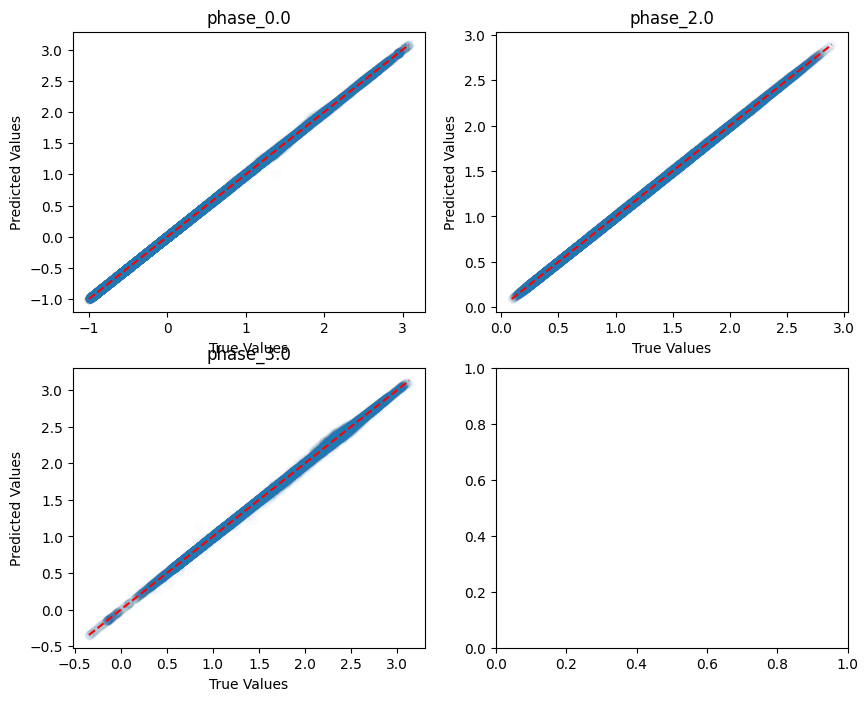

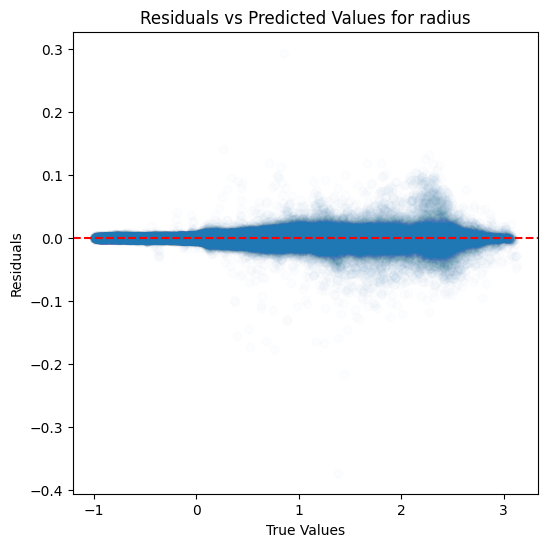

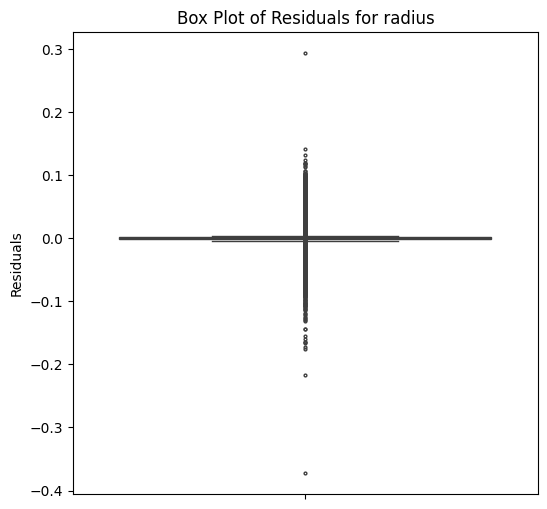

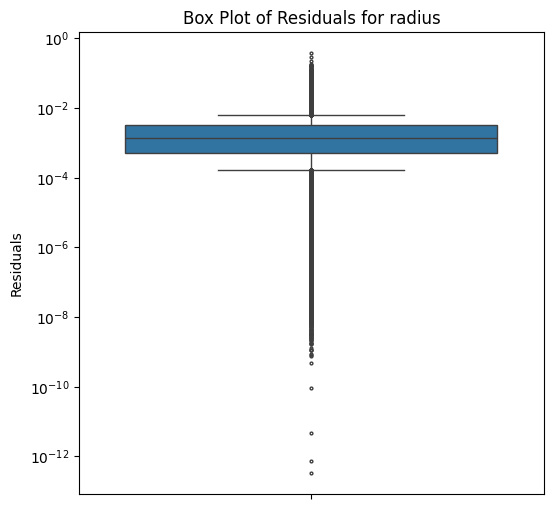

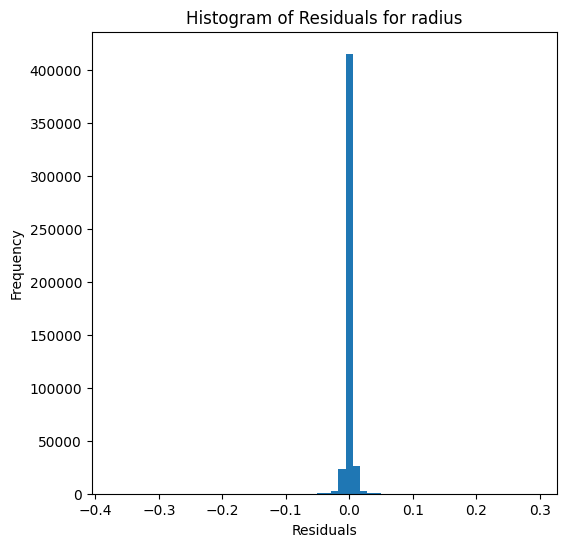

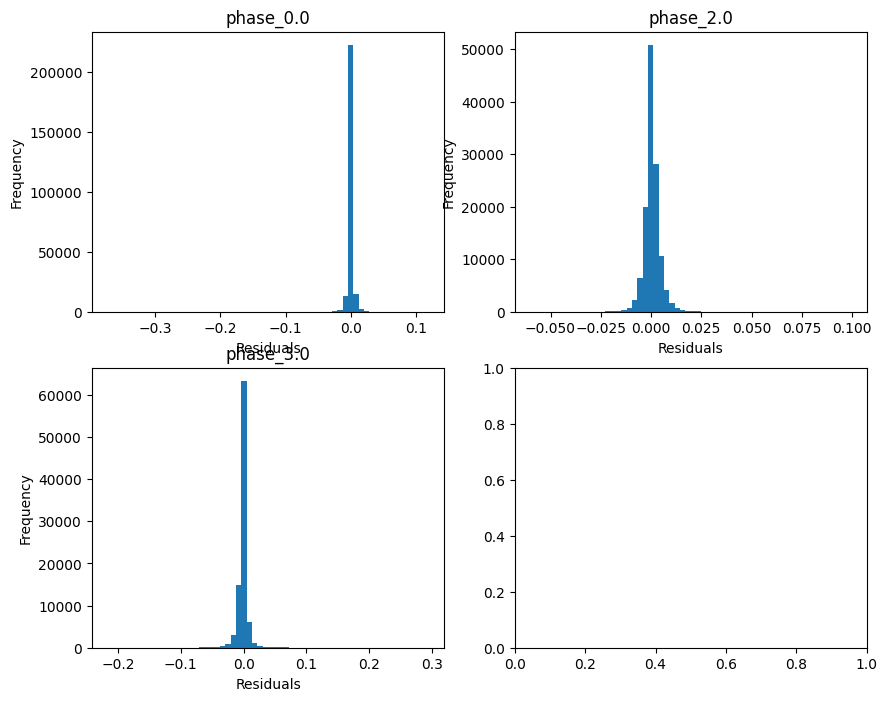

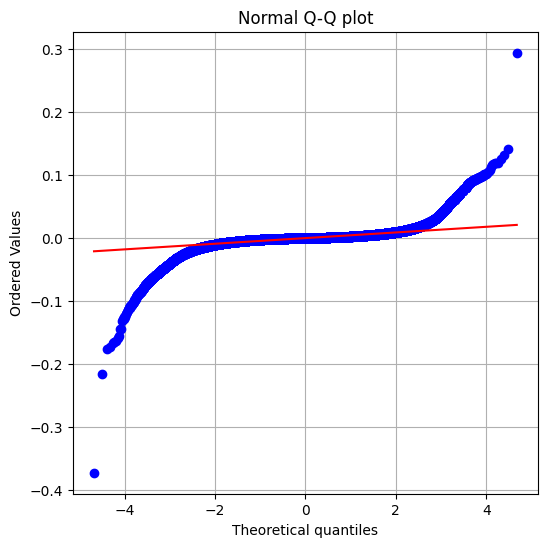

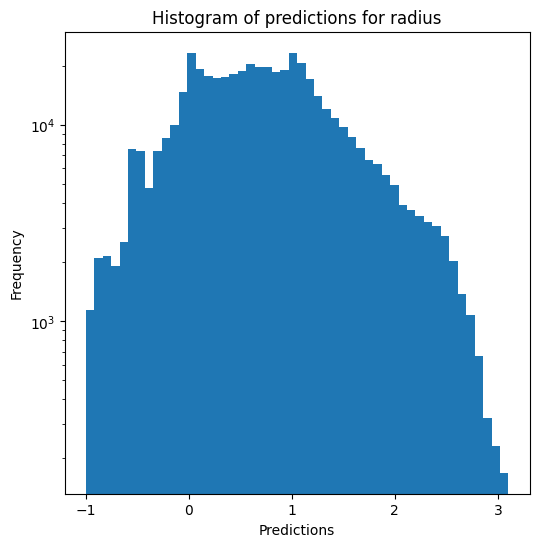

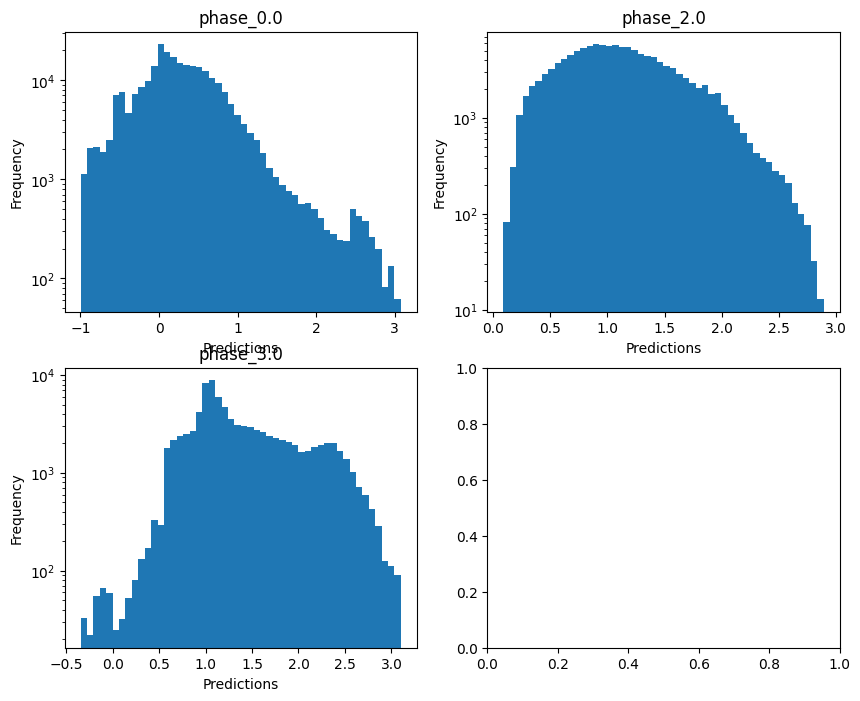

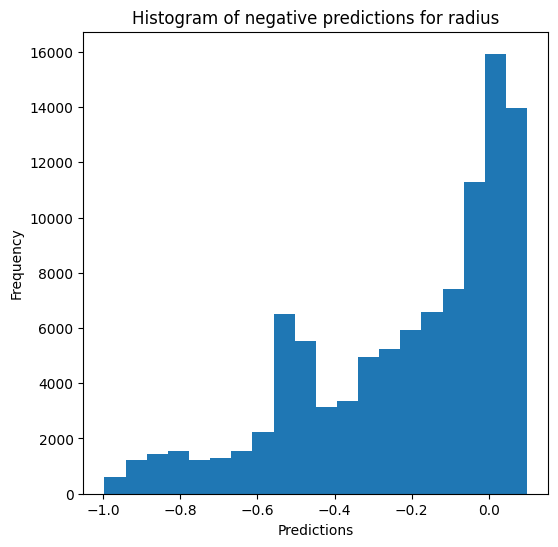

Saving predictions and results...


In [17]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)
# average depth de 44-46

### XGBoost

In [18]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9911413312819737
  RMSE :  2.4754394368688395
  MAE :  0.6786825724538321
  MedAE :  0.12799522426555154
  CORR :  0.9955746789627763
  MAX_ER :  88.78985875030139
  Percentiles : 
    75th percentile :  0.3855224486116501
    90th percentile :  1.2932559759318356
    95th percentile :  2.7172254989724482
    99th percentile :  10.991453876292315

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9987895823412088
  RMSE :  1.0332976075466853
  MAE :  0.3020403215444837
  MedAE :  0.07251355310475871
  CORR :  0.9994306690250524
  MAX_ER :  55.7601075539834
  Percentiles : 
    75th percentile :  0.16220584706985286
    90th percentile :  0.5534522528859147
    95th percentile :  1.37371566

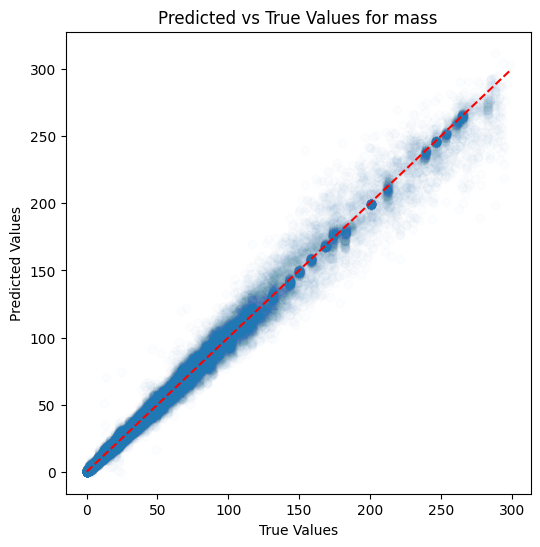

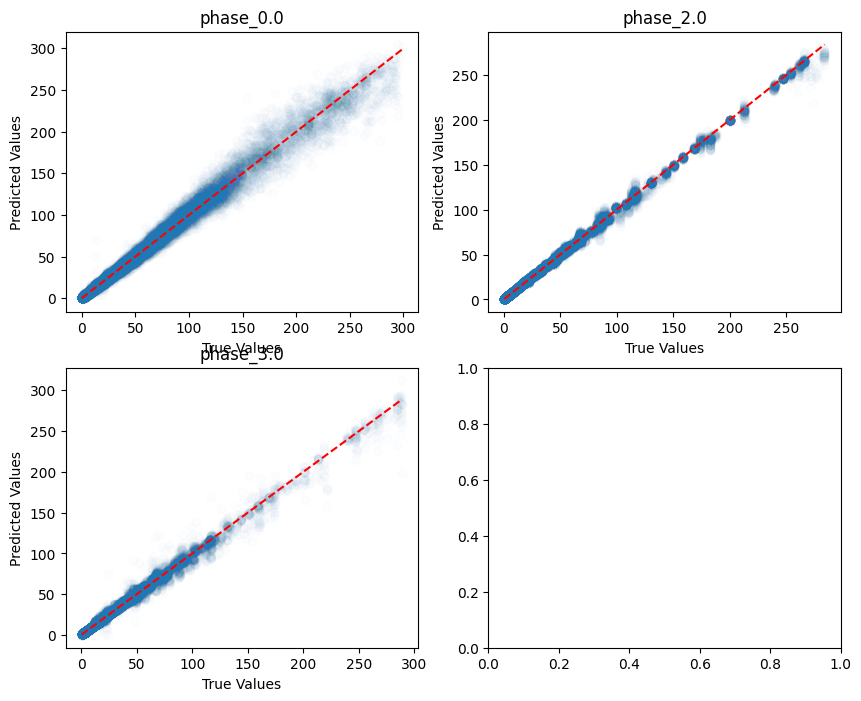

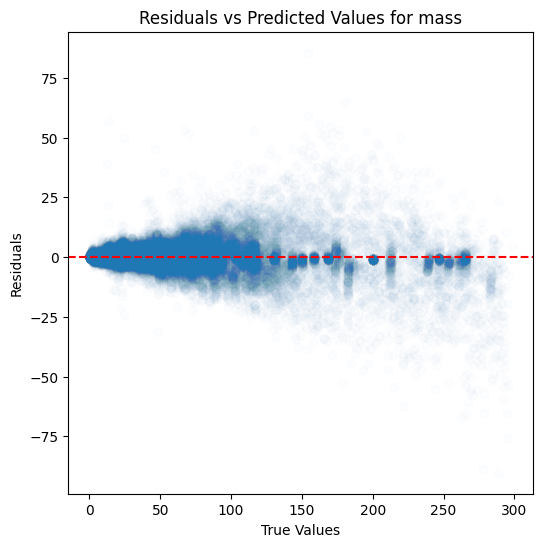

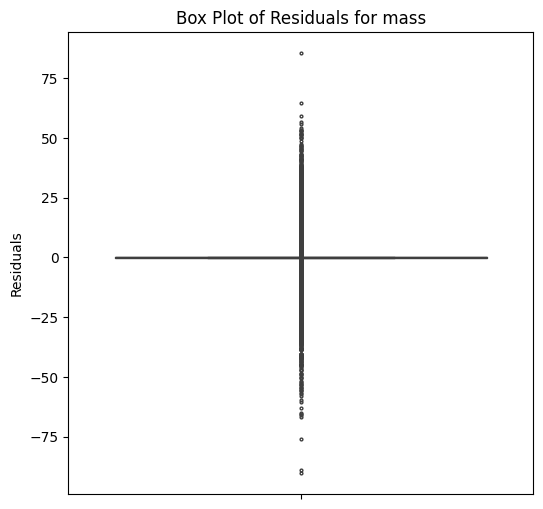

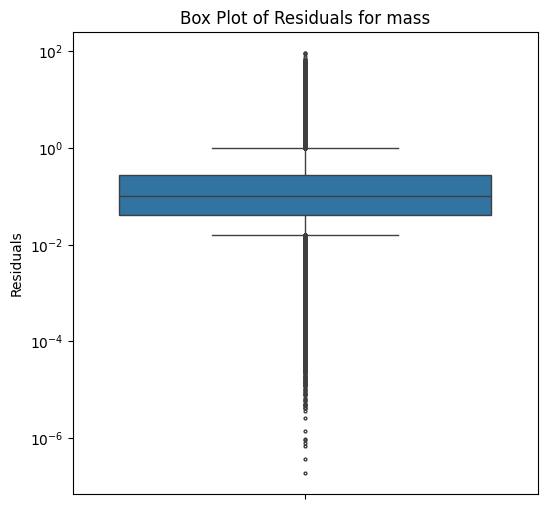

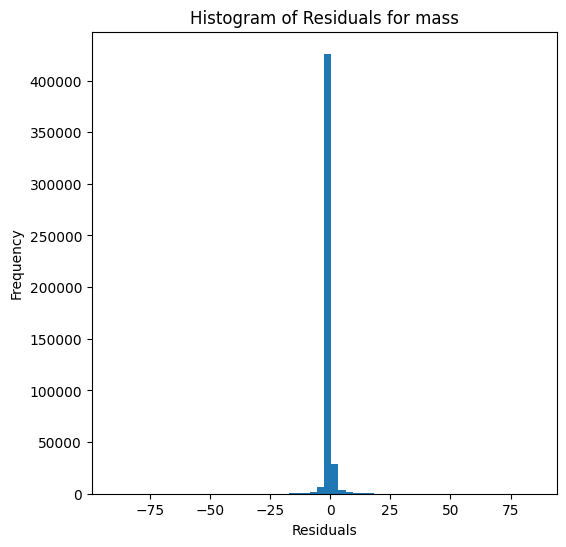

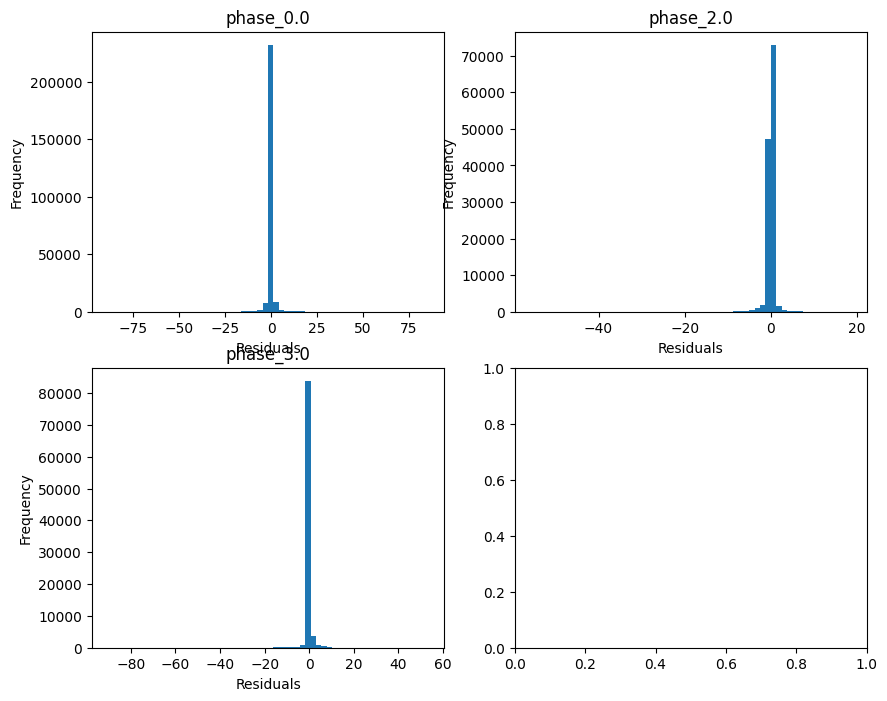

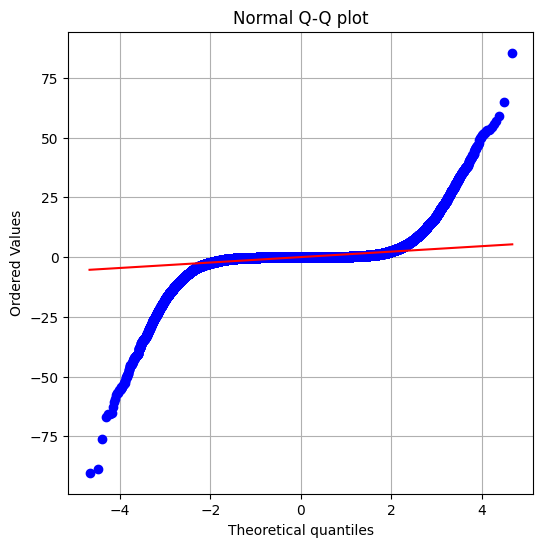

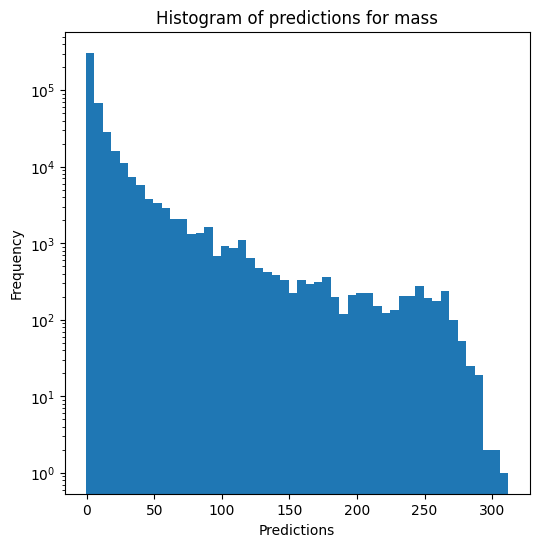

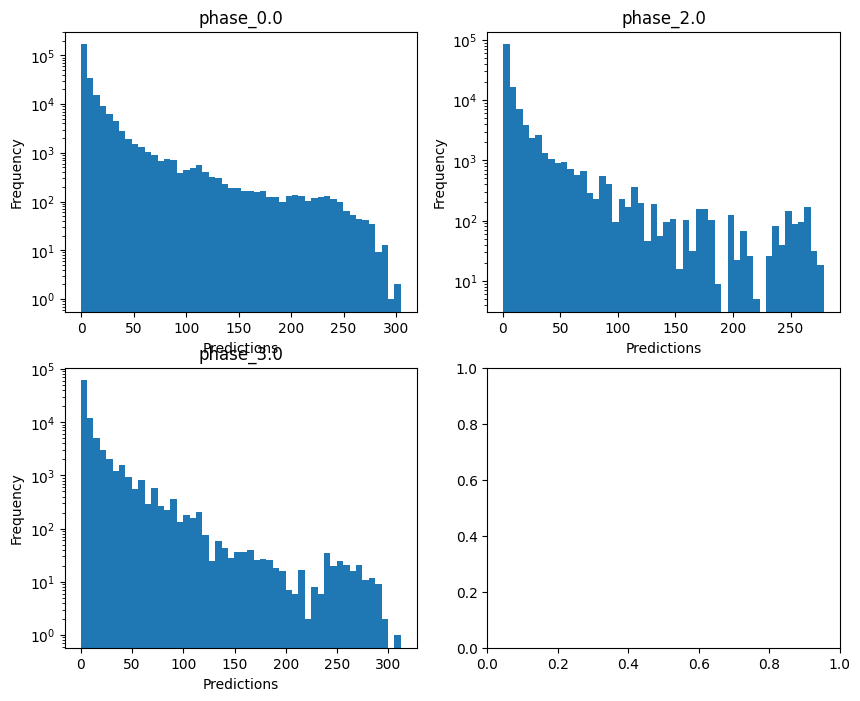

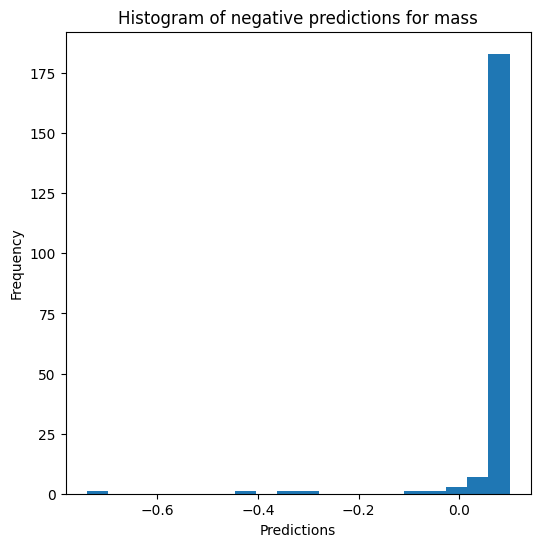


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9994280715440016
  RMSE :  0.013638657739947822
  MAE :  0.010068181125190225
  MedAE :  0.007616133676921592
  CORR :  0.9997140491652976
  MAX_ER :  0.14098964326551822
  Percentiles : 
    75th percentile :  0.013842120442423715
    90th percentile :  0.021772600324520865
    95th percentile :  0.02778177562880687
    99th percentile :  0.04220576161153632

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9992200945545977
  RMSE :  0.013718229672016885
  MAE :  0.010706141632854932
  MedAE :  0.008754332327266301
  CORR :  0.9996105096187203
  MAX_ER :  0.07709956374997606
  Percentiles : 
    75th percentile :  0.015220205513275686
    90th percentile :  0.022350739206731796
    95th percentile :  0.027345752979814914
    99th percentile :  0.03790298958103452

radius results for t

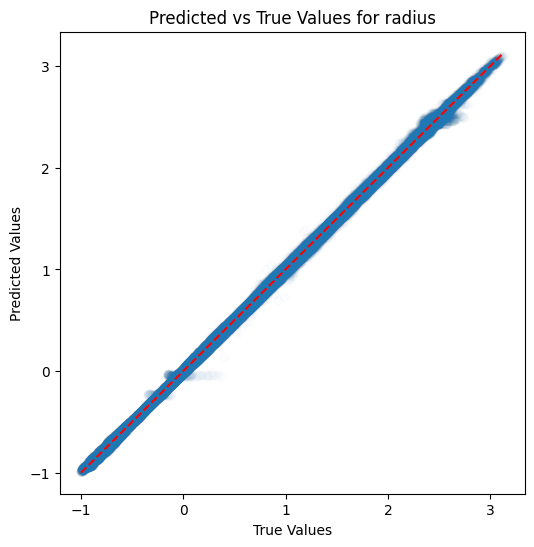

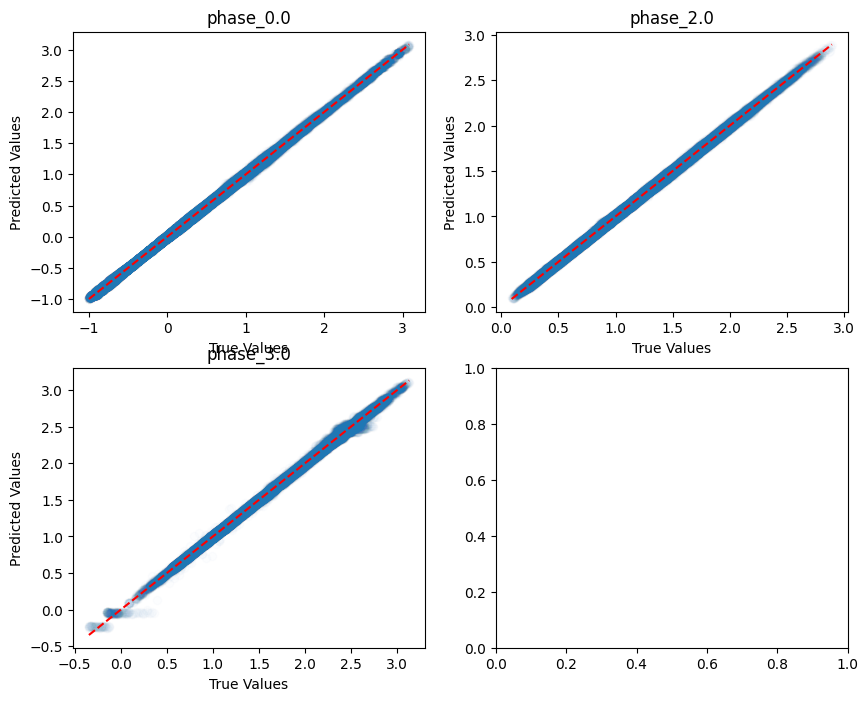

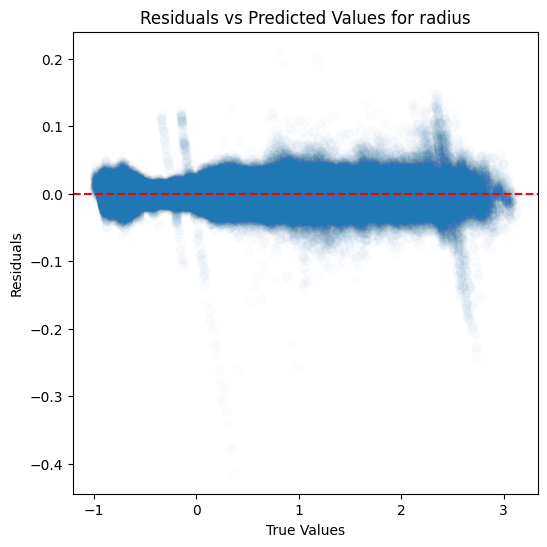

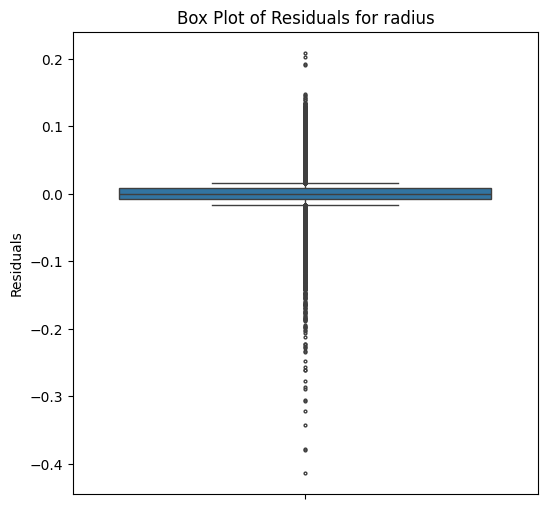

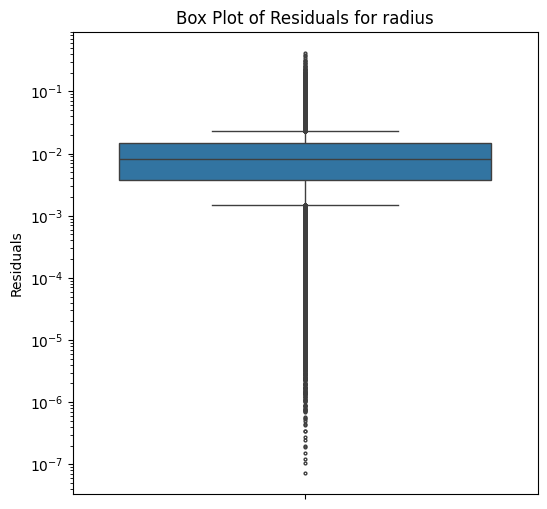

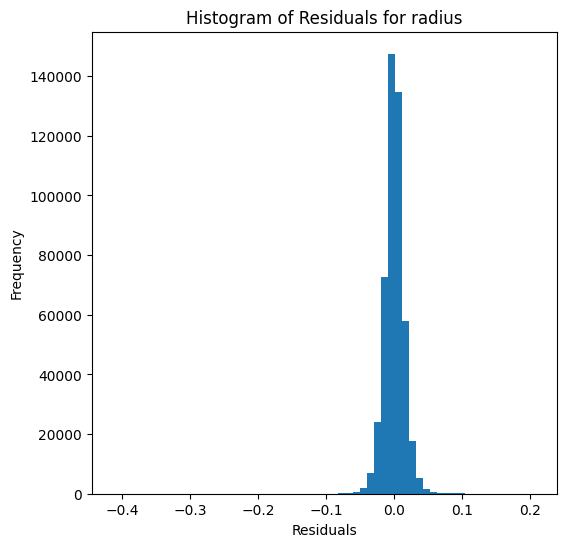

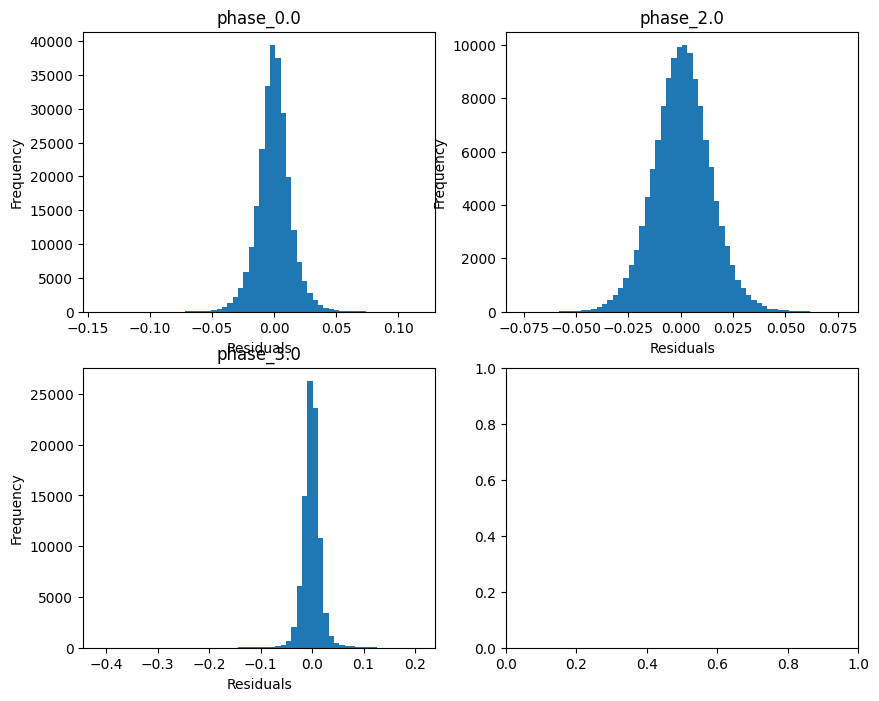

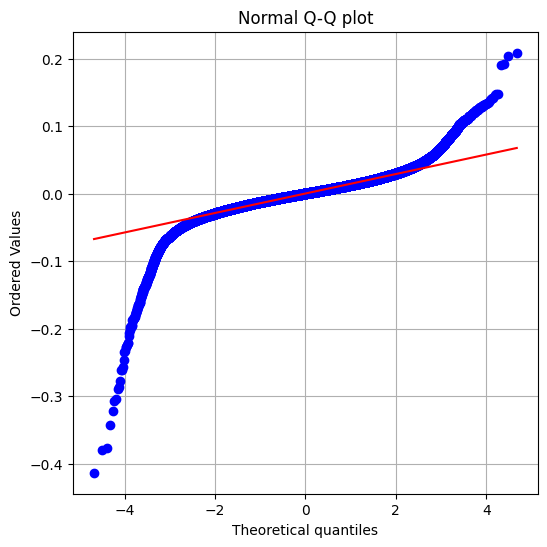

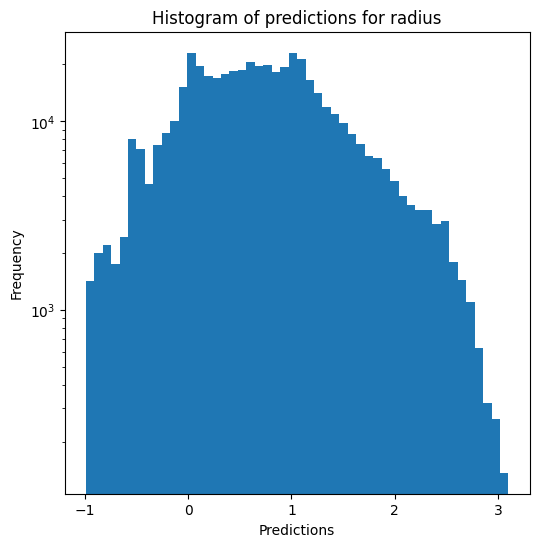

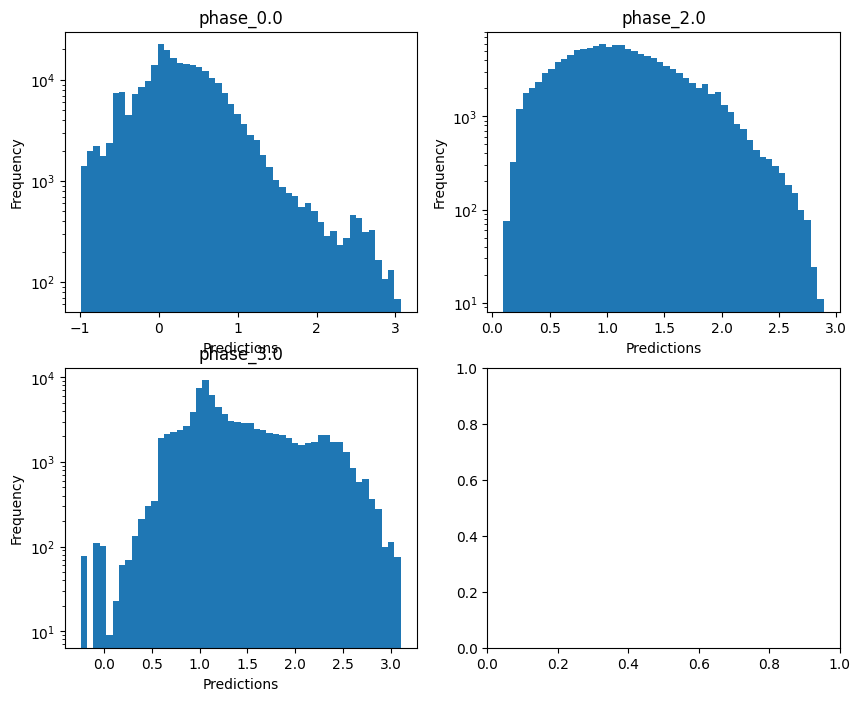

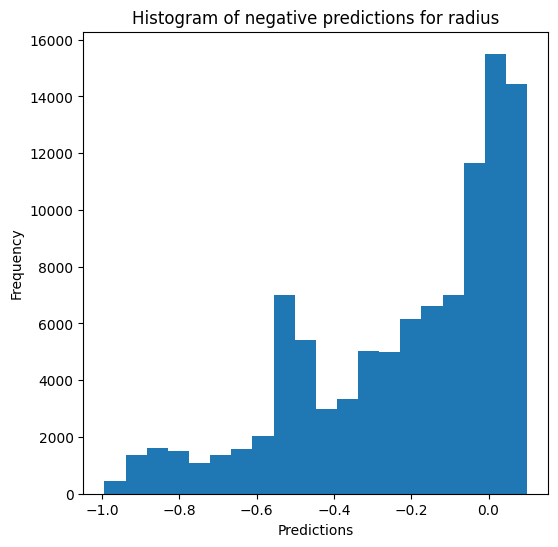

Saving predictions and results...


In [19]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)

### Multi-layer perceptron

In [20]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile train data :
Performing K-fold...
Split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


3.2221187148931683
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


3.0968606055925783
3 

...

3.3703957884070586
4 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


3.168078614047521
5 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


2.785469018860473

Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9866960390309141
  RMSE :  3.0404361185606854
  MAE :  0.9315642552195017
  MedAE :  0.24068697633333092
  CORR :  0.9934505200261949
  MAX_ER :  126.0832391155203
  Percentiles : 
    75th percentile :  0.5140717529456239
    90th percentile :  2.068238405860808
    95th percentile :  4.201256669362371
    99th percentile :  11.576002544962265

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9965522145956819
  RMSE :  1.7474548964418475
  MAE :  0.5943458491173254
  MedAE :  0.20957991997098002
  CORR :  0.998291554520482
  MAX_ER :  49.532043359873114
  Percentiles : 
    75th percentile :  0.4198733930458709
    90th percentile :  1.0905708679445822
    95th percentile :  2.4721940078507263
    99th percentile :  7.526384743191351

mass resul

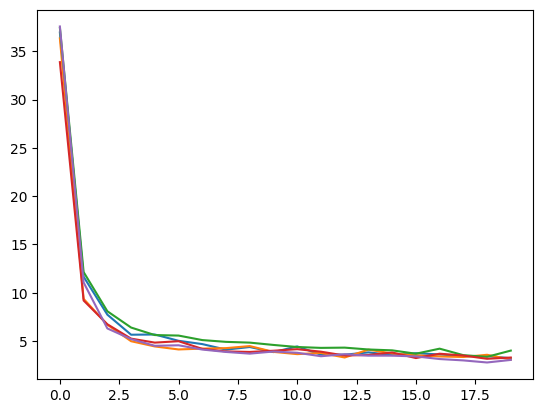

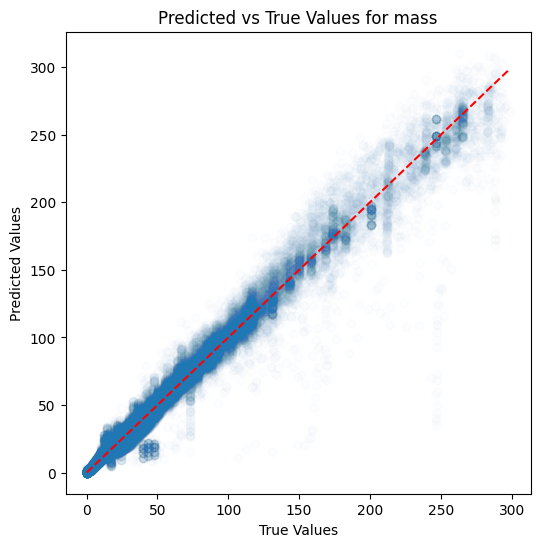

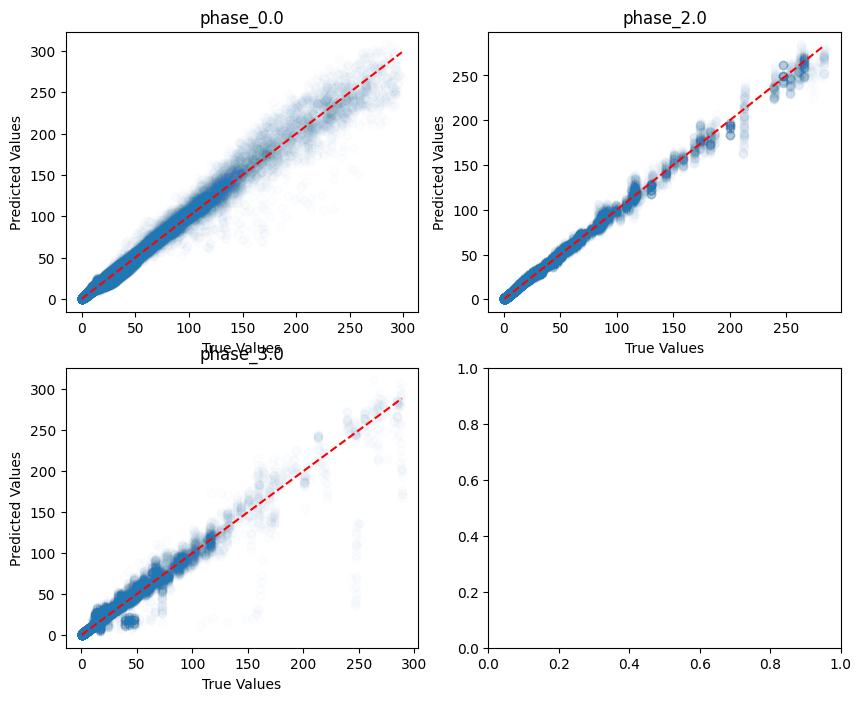

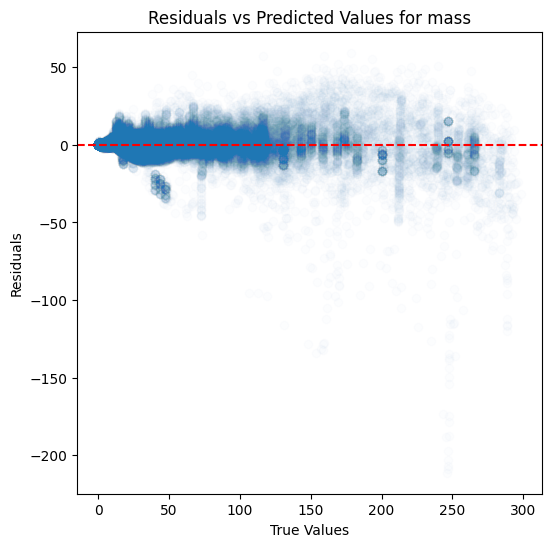

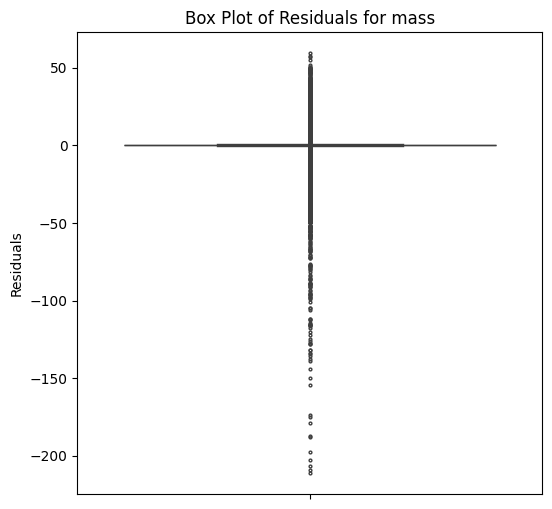

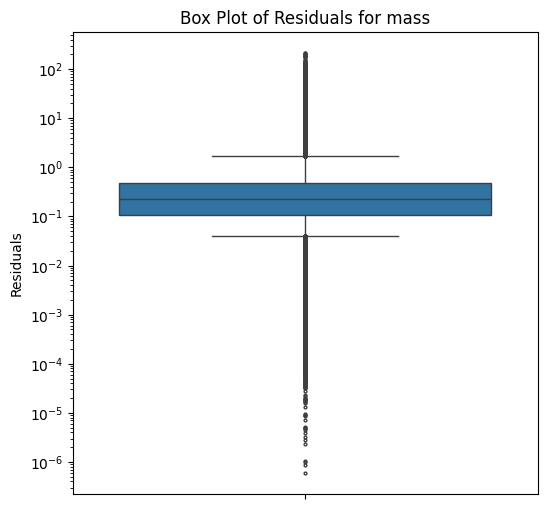

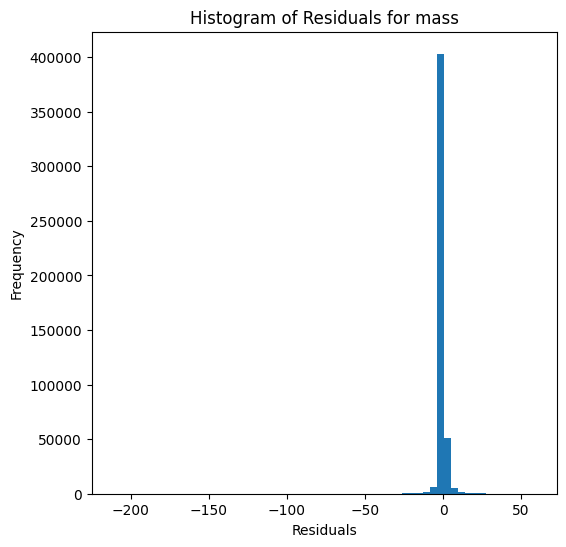

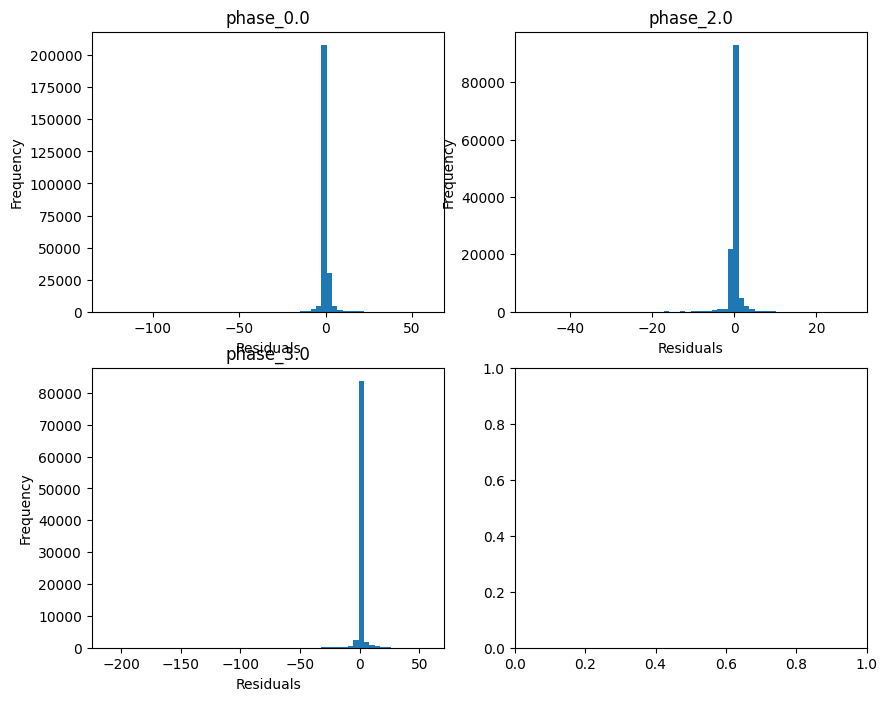

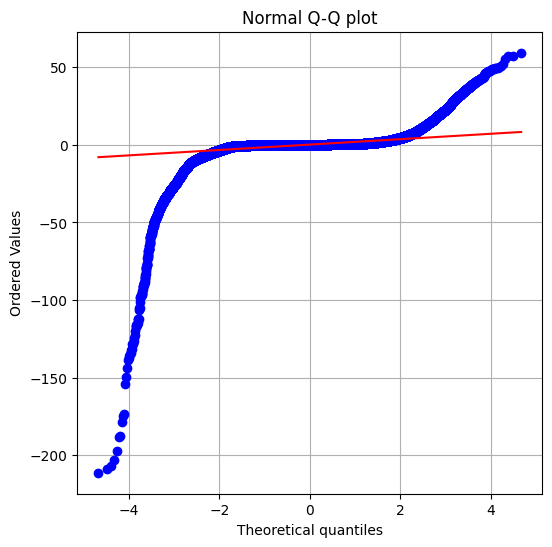

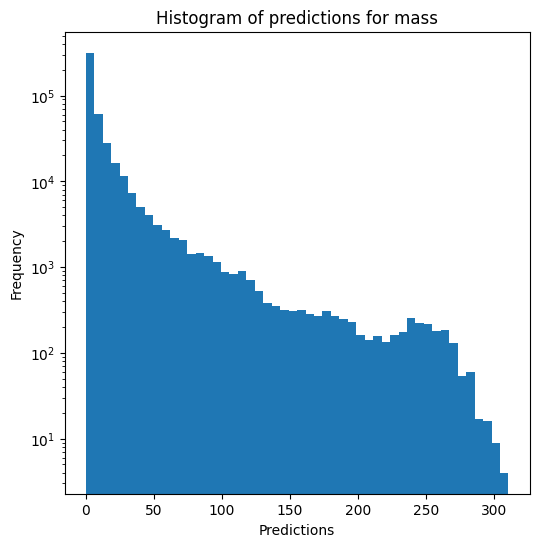

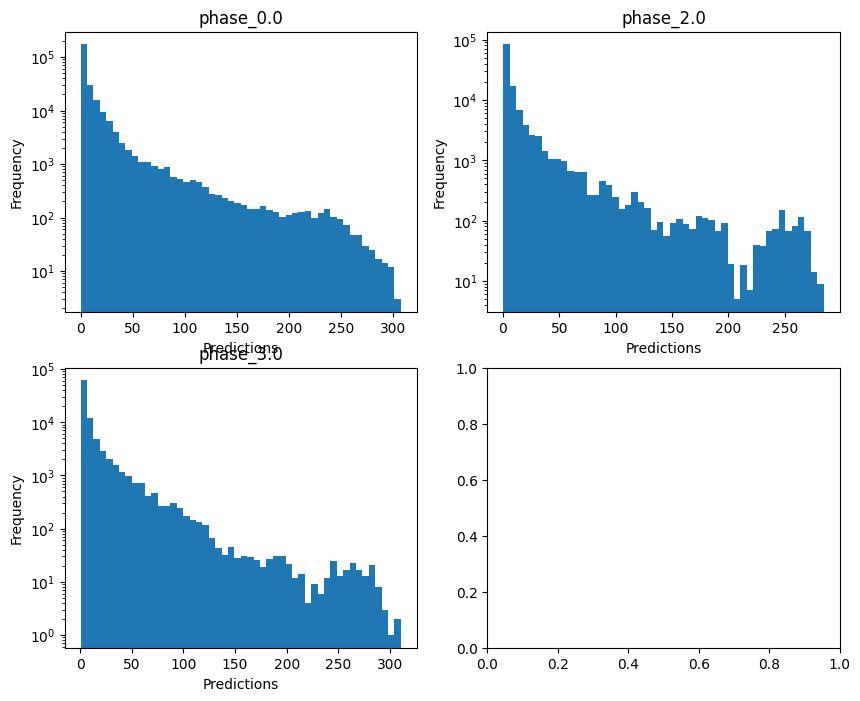

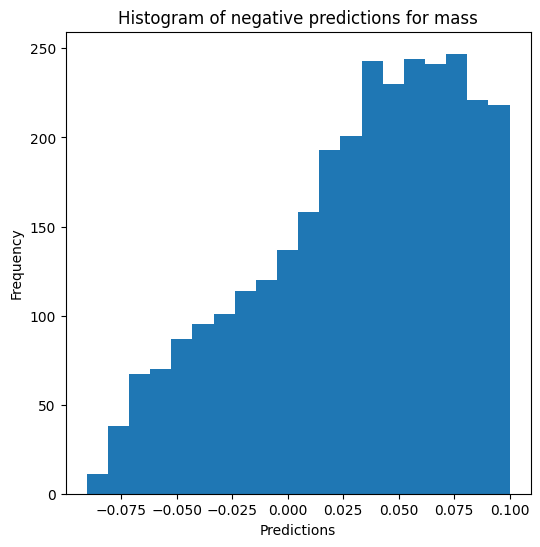


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.97026570882368
  RMSE :  0.09940641295386658
  MAE :  0.07344724335714525
  MedAE :  0.056472503599446104
  CORR :  0.9851832117844048
  MAX_ER :  0.704150004247869
  Percentiles : 
    75th percentile :  0.10032233791164241
    90th percentile :  0.15739500784542707
    95th percentile :  0.20220262353217894
    99th percentile :  0.3266997953814512

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9604660236115659
  RMSE :  0.09913518344590506
  MAE :  0.07568824736088069
  MedAE :  0.060290148382352804
  CORR :  0.980407942139034
  MAX_ER :  0.6014340076257969
  Percentiles : 
    75th percentile :  0.10499532161994102
    90th percentile :  0.15921840637130993
    95th percentile :  0.19946866002971853
    99th percentile :  0.29227798995610105

radius results for the phase categor

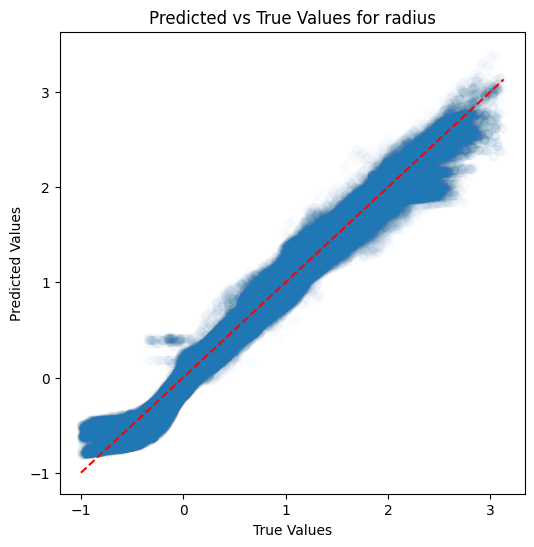

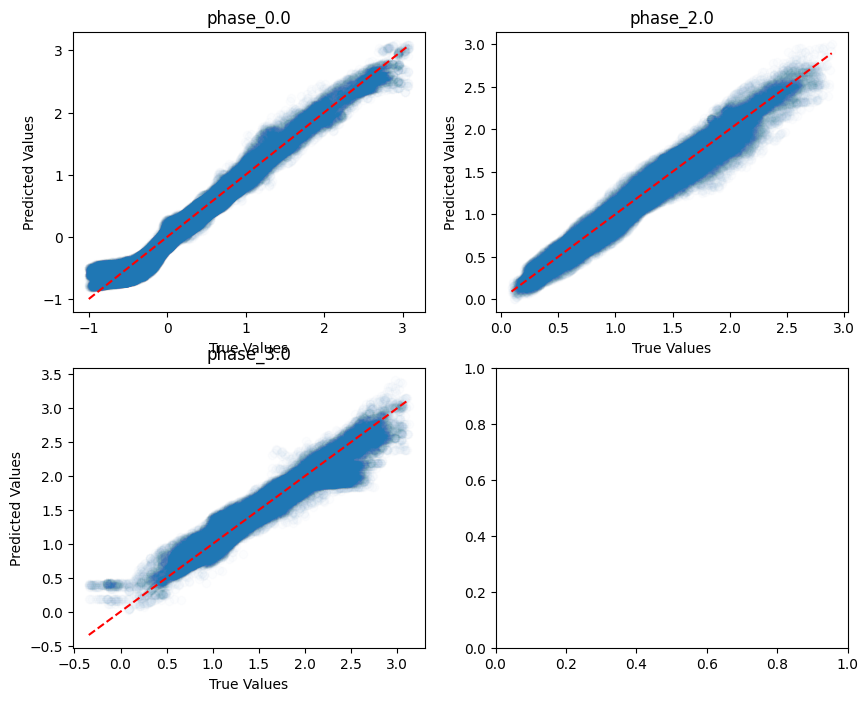

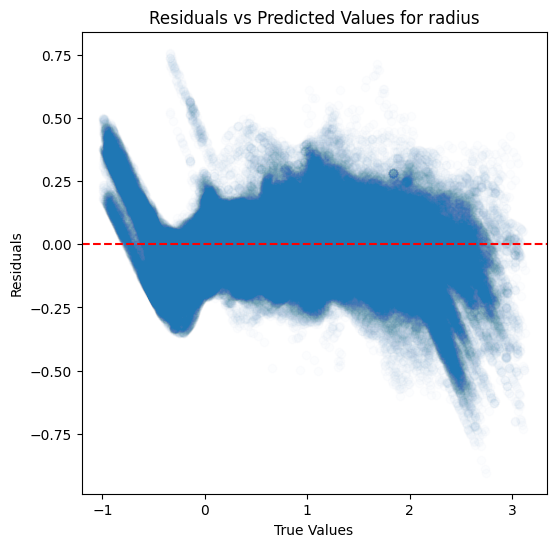

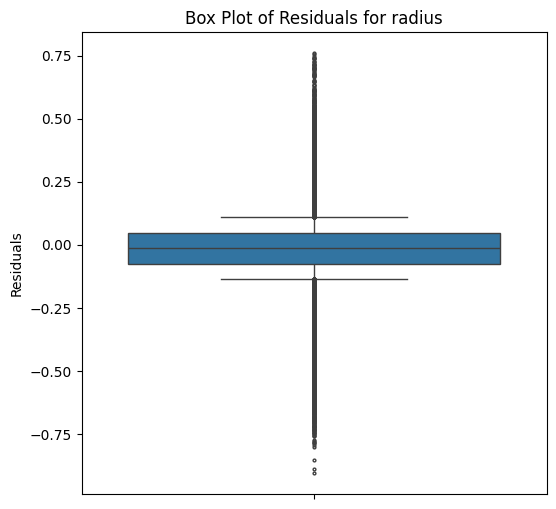

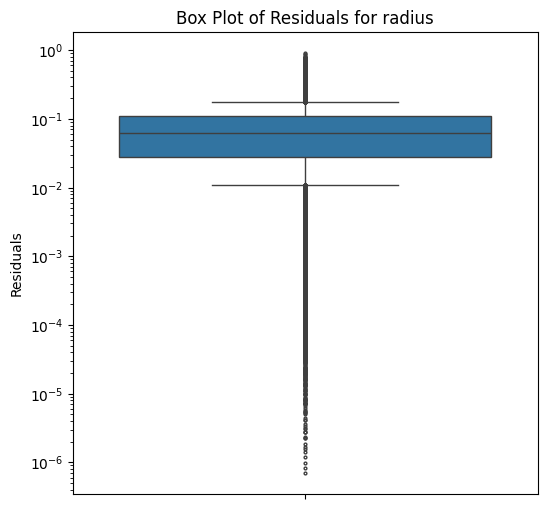

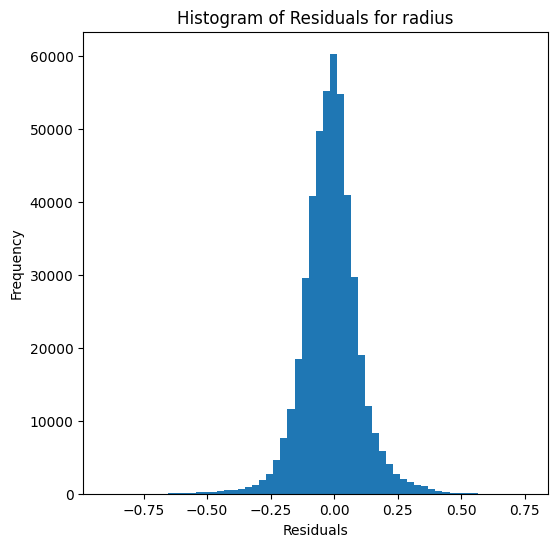

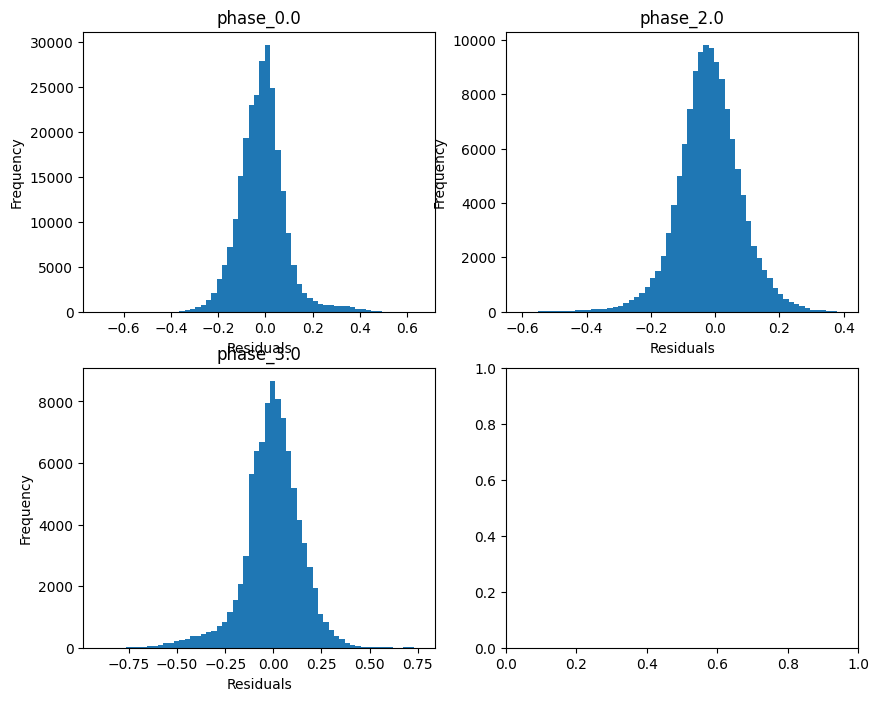

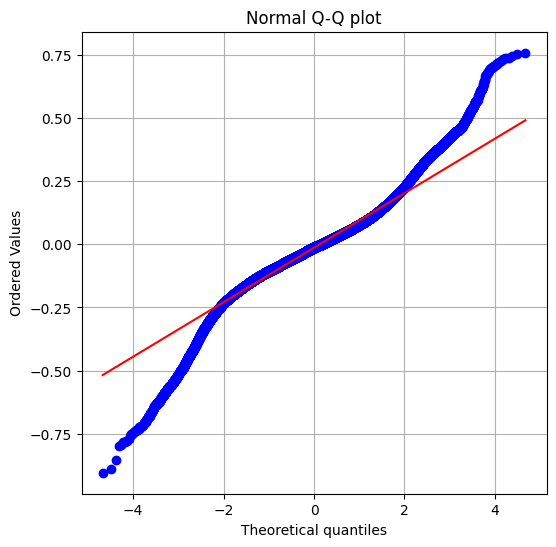

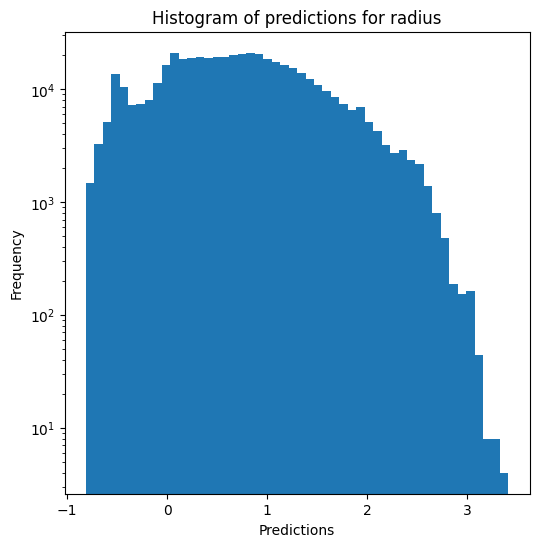

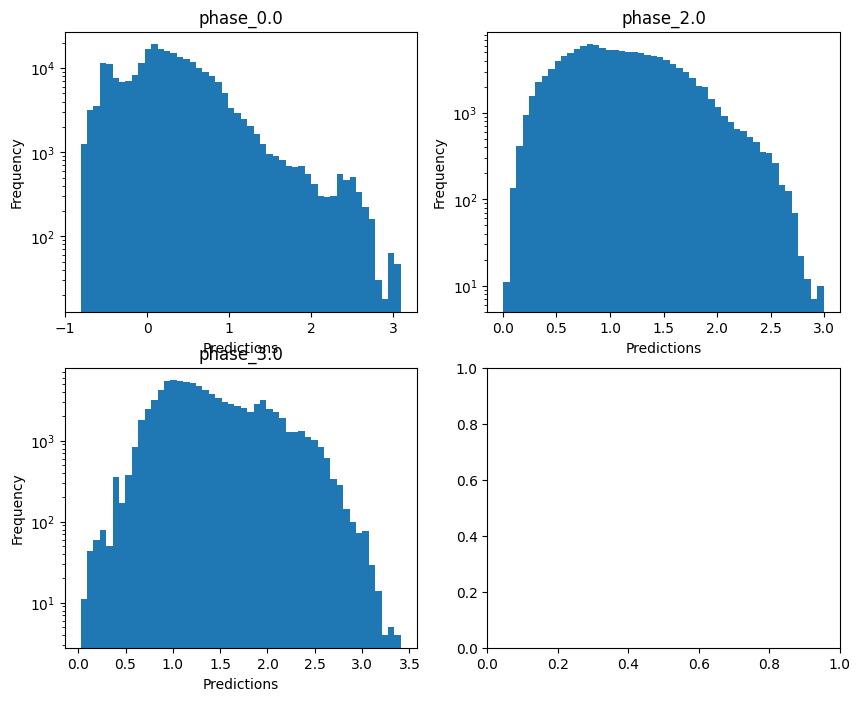

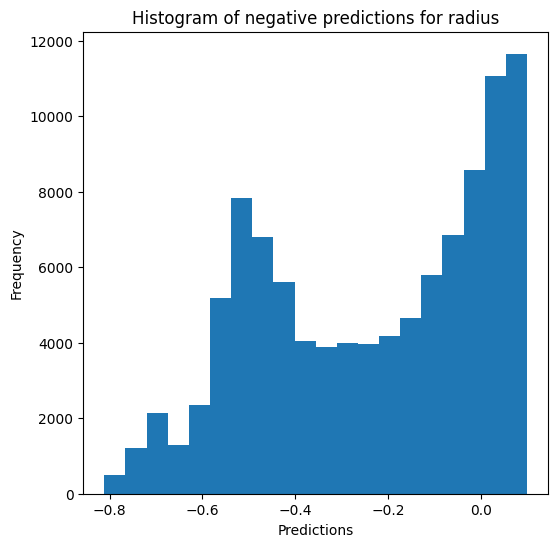

Saving predictions and results...


In [21]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon